# HERCULES analysis - read in HERCULES outputs

In [1]:
# Record the verions information for these calculation for posterity
import platform
print('python version: ',platform.python_version())
del platform
import matplotlib
print('matplotlib version: ', matplotlib.__version__)
del matplotlib
import numpy
print('numpy version: ', numpy.__version__)
del numpy
import scipy
print('scipy version: ', scipy.__version__)
del scipy

import sys

import woma
from woma.misc import glob_vars as gv
from woma.eos import sesame
from woma.eos.T_rho import T_rho

R_earth = gv.R_earth #6.371e6   # m
M_earth = gv.M_earth #5.9724e24  # kg 
G = gv.G #6.67408e-11  # m^3 kg^-1 s^-2
LEM=3.5E34 #AMof Earth-Moon system in mks

# First we import python libraries
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy import interpolate
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import colormaps as local_cmaps
import os
from copy import deepcopy
from pathlib import Path
import pkgutil
import h5py
import yaml
print(yaml.__version__)
from HERCULES_structures import *
from isentrope_planet import *

%run eostable.py

%config InlineBackend.figure_format = 'retina'

plt.rcParams["figure.figsize"] = (20,10) # default figure size in inches

#eospath = os.path.expanduser('~') + '/Work/'
eospath = '../'

mant_mat_id = 403 #USER INPUT
core_mat_id = 402 #USER INPUT

python version:  3.14.2
matplotlib version:  3.10.8
numpy version:  2.3.5
scipy version:  1.16.3
6.0.3


In [2]:
def gradient2(x,y):
    #define the difference between all the points
    dx=np.diff(x)
    #define the output array
    dydx=np.empty(np.size(y))
    #use centered difference for the middle points
    dydx[1:-1]=(y[2:]*(dx[0:-1]**2.0)-y[0:-2]*(dx[1:]**2.0)-y[1:-1]*((dx[0:-1]**2.0)-
                        (dx[1:]**2.0)))/(dx[0:-1]*dx[1:]*(dx[1:]+dx[0:-1]))
    #use forward diff for first point
    dydx[0]=(y[2]*(dx[0]**2)-y[1]*((dx[1]+dx[0])**2)-y[0]*((dx[0]**2)-((dx[1]+dx[0])**2)))/(dx[0]*(dx[0]+dx[1])*-dx[1])
    #use backwards difference for the last point
    dydx[-1]=(y[-3]*(dx[-1]**2)-y[-2]*((dx[-1]+dx[-2])**2)-y[-1]*((dx[-1]**2)-((dx[-1]+dx[-2])**2)))/(dx[-1]*(dx[-1]+dx[-2])*dx[-2])
    return dydx

In [3]:
class HERC_run:
    def __init__(self,planet=None):
        self.planet=None
        self.M = 0.
        self.Mcore = 0.
        self.Mmant = 0.
        self.r10 = 0.
        self.rCMB0 = 0.
        self.PCMB0 = 0.
        self.Pcore0 = 0.
        self.basename = ''
        if planet is not None:
            self.load_planet(planet)
        self.keys = np.array([])
        self.paramsdict = dict()
        self.planetdict = dict()
        self.Ltot = np.array([])
        self.PCMB = np.array([])
        self.Pcore = np.array([])
        self.r1 = np.array([])
        self.b1 = np.array([])
        self.rCMB = np.array([])
        self.bCMB = np.array([])
        self.aspect = np.array([])
        self.w = np.array([])
    
    def load_planet(self,planet):
        if planet.file is None:
            print('Error: tried to load empty planet')
            return
        planet.convert_to_mks()
        self.planet=planet # this is the planet_profile object that defines the HERCULES ICs
        self.M=self.planet.M
        indcore=np.where(self.planet.mat==core_mat_id)
        self.Mcore=self.planet.mass[indcore][-1]
        self.Mmant=self.M-self.Mcore
        self.r10=self.planet.rarr[-1]
        self.rCMB0=self.planet.rarr[indcore][-1]
        self.PCMB0=self.planet.pressure[indcore][-1]
        self.Pcore0=self.planet.pressure[0]
        self.Lzstar=self.planet.Lzstar
        #self.Lfinal=((self.M/M_earth)**2*5+1)*LEM
        # finding basename, expecting the file to be in the planet_profiles folder
        #print(np.char.split(planet.file,'/'))
        split=np.char.split(planet.file,'/').item()[2]
        print(split)
        self.basename=np.char.split(split,'N').item()[0] #assuming the same naming format as in MakePlanets
        
    def load_data(self,path='./'):
        for filename in os.listdir(path):
            if filename.startswith(self.basename) and filename.endswith('final'):
                print(filename)
                temp = filename.replace(self.basename+'_','')
                keyparams = temp.replace('_final','')
                tparams = HERCULES_parameters()
                tparams.flag_output_format=1
                tparams.thermo_var_output=['T','S','E']
                tplanet = HERCULES_planet()
                tplanet.flag_output_format=1
                tplanet.thermo_var_output=['T','S','E']
                try:   
                    try:
                        with open(path+filename, "rb") as file:
                            tparams.read_binary(file)
                            tplanet.read_binary(file,1,['T','S','E'])
                    except:
                        print('ERROR: READ WITH FORMAT 1 UNSUCCESSFUL')
                        tparams.flag_output_format=0
                        tplanet.flag_output_format=0
                        with open(path+filename, "rb") as file:
                            tparams.read_binary(file)
                            tplanet.read_binary(file,0,['T','S','E'])

                    tplanet.calc_pCMB()
                    print('Loaded HERCULES output ',filename)
                    self.keys=np.append(self.keys,keyparams)
                    self.paramsdict[keyparams]=tparams
                    self.planetdict[keyparams]=tplanet
                    self.Ltot=np.append(self.Ltot,tplanet.Ltot)
                    self.PCMB=np.append(self.PCMB,tplanet.pCMB)
                    self.Pcore=np.append(self.Pcore,tplanet.pcore)
                    self.r1=np.append(self.r1,tplanet.amax)
                    self.b1=np.append(self.b1,tplanet.layers[0].b)
                    #self.b1=np.append(self.b1,tplanet.layers[0].xi[-1]*tplanet.layers[0].a*tplanet.layers[0].mu[-1])
                    self.w=np.append(self.w,tplanet.omega_rot)
                    core_layer=tplanet.Nmaterial-1
                    #ind=np.where(tplanet.flag_material==core_layer)[0]
                    ind=np.where(tplanet.flag_material>0)[0][0]
                    #print(ind)
                    #print(tplanet.layers[ind])
                    self.rCMB=np.append(self.rCMB,tplanet.layers[ind].a)
                    print(tplanet.layers[ind].a)
                    self.bCMB=np.append(self.bCMB,tplanet.layers[ind].b)
                    #self.bCMB=np.append(self.bCMB,tplanet.layers[ind[0]].xi[-1]*tplanet.layers[ind[0]].a*tplanet.layers[ind[0]].mu[-1])
                    self.aspect=np.append(self.aspect,tplanet.aspect)
                except:
                    print('ERROR: READ UNSUCCESSFUL. SKIPPING FILE')
        sort=np.argsort(self.Ltot)
        self.keys = self.keys[sort]
        self.Ltot = self.Ltot[sort]
        self.PCMB = self.PCMB[sort]
        self.Pcore = self.Pcore[sort]
        self.r1 = self.r1[sort]
        self.rCMB = self.rCMB[sort]
        self.w = self.w[sort]

        self.b1 = self.b1[sort]
        #self.rCMB = self.rCMB[sort]
        self.bCMB = self.bCMB[sort]
        self.aspect = self.aspect[sort]
        #self.w = self.w[sort]

In [4]:
filelist = np.array([])
masslist = np.array([])
planetdict = {}
hercdict = {}
for filename in os.listdir("./planet_profiles/"):
    if filename.endswith(".txt") and not filename.endswith(".used_params.txt"):
        if filename.startswith("MO") or filename.startswith("DMO") or filename.startswith("HMO") or filename.startswith("PMO"):
            pass
        #print(filename)
        else:
            path = './planet_profiles/'+filename
            basename=np.char.split(filename,'N').item()[0] #assuming the same naming format as in MakePlanets
            filelist = np.append(filelist,basename)
            planet = planet_profile(file=path)
            planetdict[basename] = planet
            hercrun = HERC_run(planet=planet)
            hercdict[basename] = hercrun
            hercrun.load_data(path='./output/')
            masslist=np.append(masslist,hercrun.M)

masssort = masslist[np.argsort(masslist)]
keylist=filelist[np.argsort(masslist)]

M.0017PyroSCmantleSMwarmN29_fulltension.txt
M.0017PyroSCmantleSMwarm_L0.000100005_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000100005_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
748278.3222279854
M.0017PyroSCmantleSMwarm_L0.000100005_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000100005_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
748278.2530212103
M.0017PyroSCmantleSMwarm_L0.000102862_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000102862_N150_

In [6]:
MOfilelist = np.array([])
MOmasslist = np.array([])
MOplanetdict = {}
MOhercdict = {}
for filename in os.listdir("./planet_profiles/"):
    if filename.endswith(".txt") and not filename.endswith(".used_params.txt"):
        if filename.startswith("MO") or filename.startswith("DMO") or filename.startswith("HMO") or filename.startswith("PMO"):
            path = './planet_profiles/'+filename
            basename=np.char.split(filename,'N').item()[0] #assuming the same naming format as in MakePlanets
            MOfilelist = np.append(MOfilelist,basename)
            planet = planet_profile(file=path)
            MOplanetdict[basename] = planet
            hercrun = HERC_run(planet=planet)
            MOhercdict[basename] = hercrun
            hercrun.load_data(path='./output/')
            MOmasslist=np.append(MOmasslist,hercrun.M)
            

MOmasssort = MOmasslist[np.argsort(MOmasslist)]
MOkeylist=MOfilelist[np.argsort(MOmasslist)]

DMO_M0.455PyroSChotSMhotN128.txt
DMO_M0.55PyroSChotSMhotN128.txt
DMO_M0.65PyroSChotSMhotN128.txt
DMO_M0.706PyroSChotSMhotN128.txt
DMO_M0.91PyroSChotSMhotN128.txt
DMO_M1.3PyroSChotSMhotN128.txt
DMO_M1.5PyroSChotSMhotN128.txt
DMO_M1.9PyroSChotSMhotN128.txt
HMO_M0.706PyroSChotSMhotN128.txt
HMO_M0.91PyroSChotSMhotN128.txt
HMO_M1.3PyroSChotSMhotN128.txt
HMO_M1.5PyroSChotSMhotN128.txt
HMO_M1.9PyroSChotSMhotN128.txt
MO_M0.455PyroSChotSMhotN128.txt
MO_M0.55PyroSChotSMhotN128.txt
MO_M0.65PyroSChotSMhotN128.txt
MO_M0.706PyroSChotSMhotN128.txt
MO_M0.91PyroSChotSMhotN128.txt
MO_M1.3PyroSChotSMhotN128.txt
MO_M1.5PyroSChotSMhotN128.txt
MO_M1.9PyroSChotSMhotN128.txt
PMO_M0.706PyroSChotSMhotN128.txt
PMO_M0.91PyroSChotSMhotN128.txt
PMO_M1.3PyroSChotSMhotN128.txt
PMO_M1.5PyroSChotSMhotN128.txt
PMO_M1.9PyroSChotSMhotN128.txt


In [7]:
def xi_ellipsoid(mu,a,b):
    return b/np.sqrt(b**2-b**2*mu**2+a**2*mu**2)

1.8989924820842543


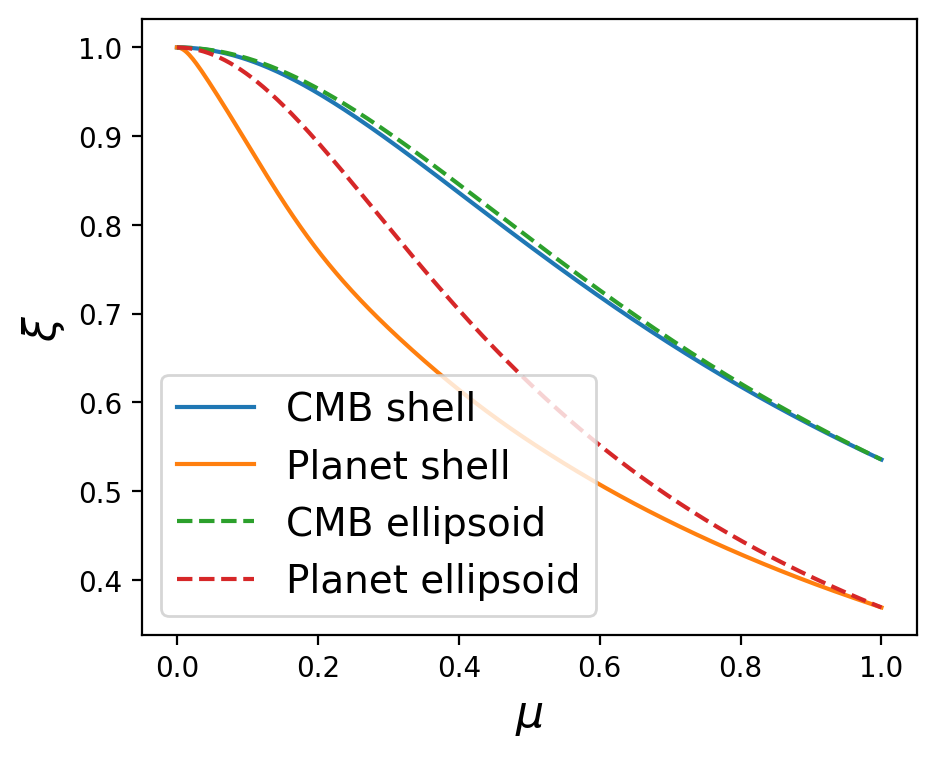

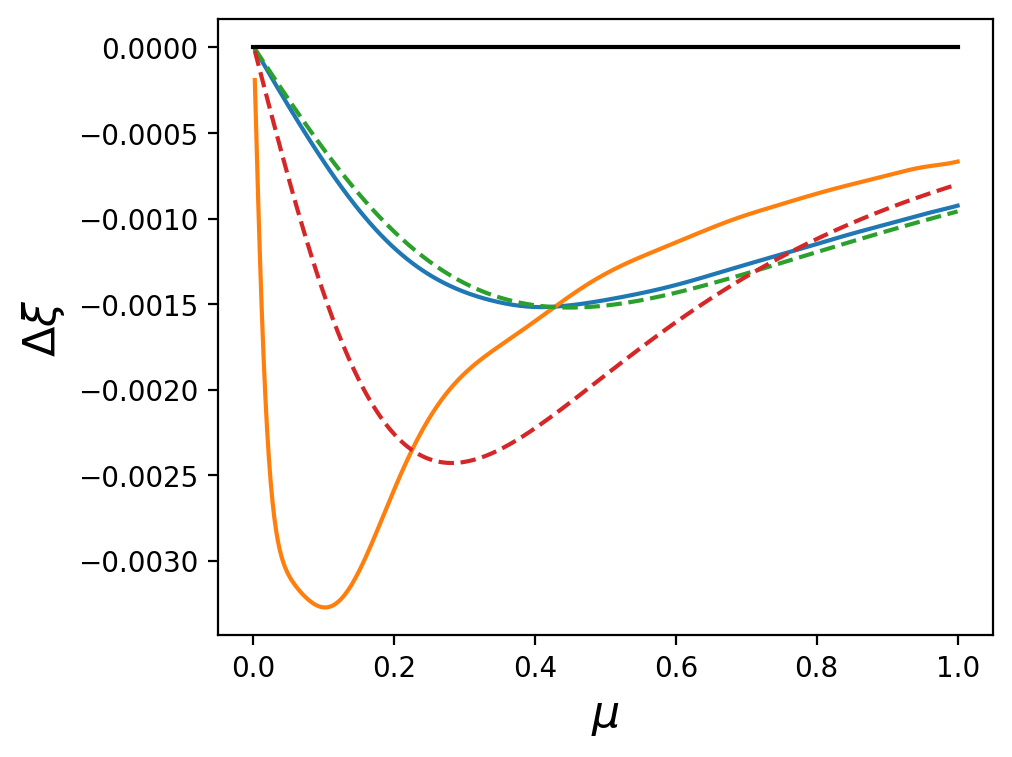

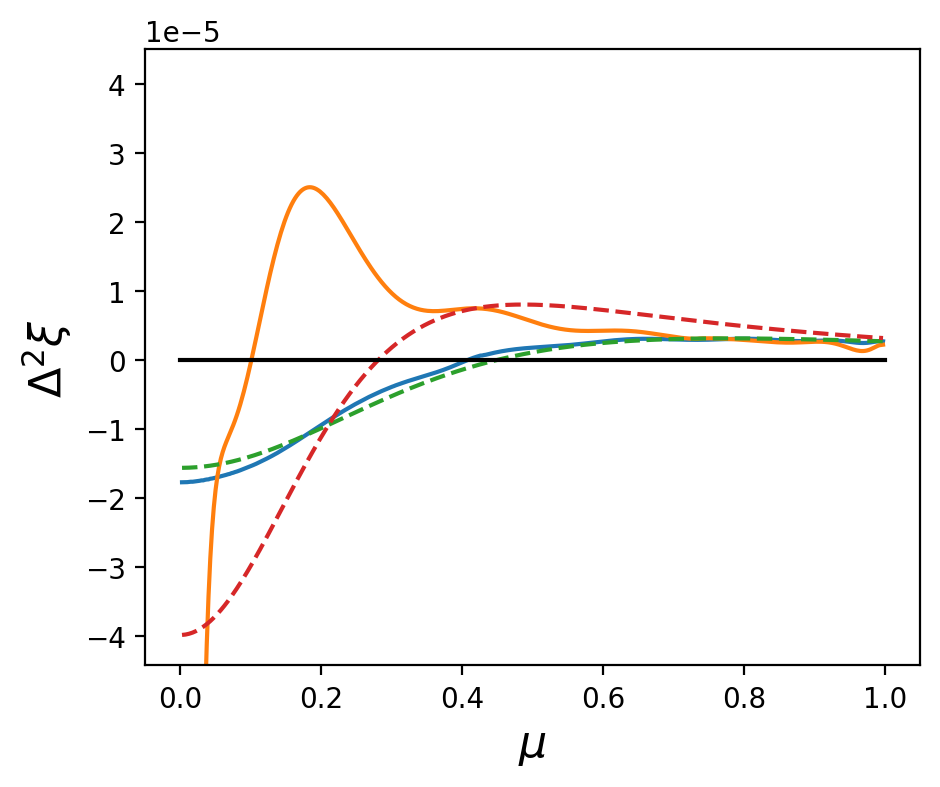

11.123254544900673 -1
Maximum L seen: 11.228208718686973


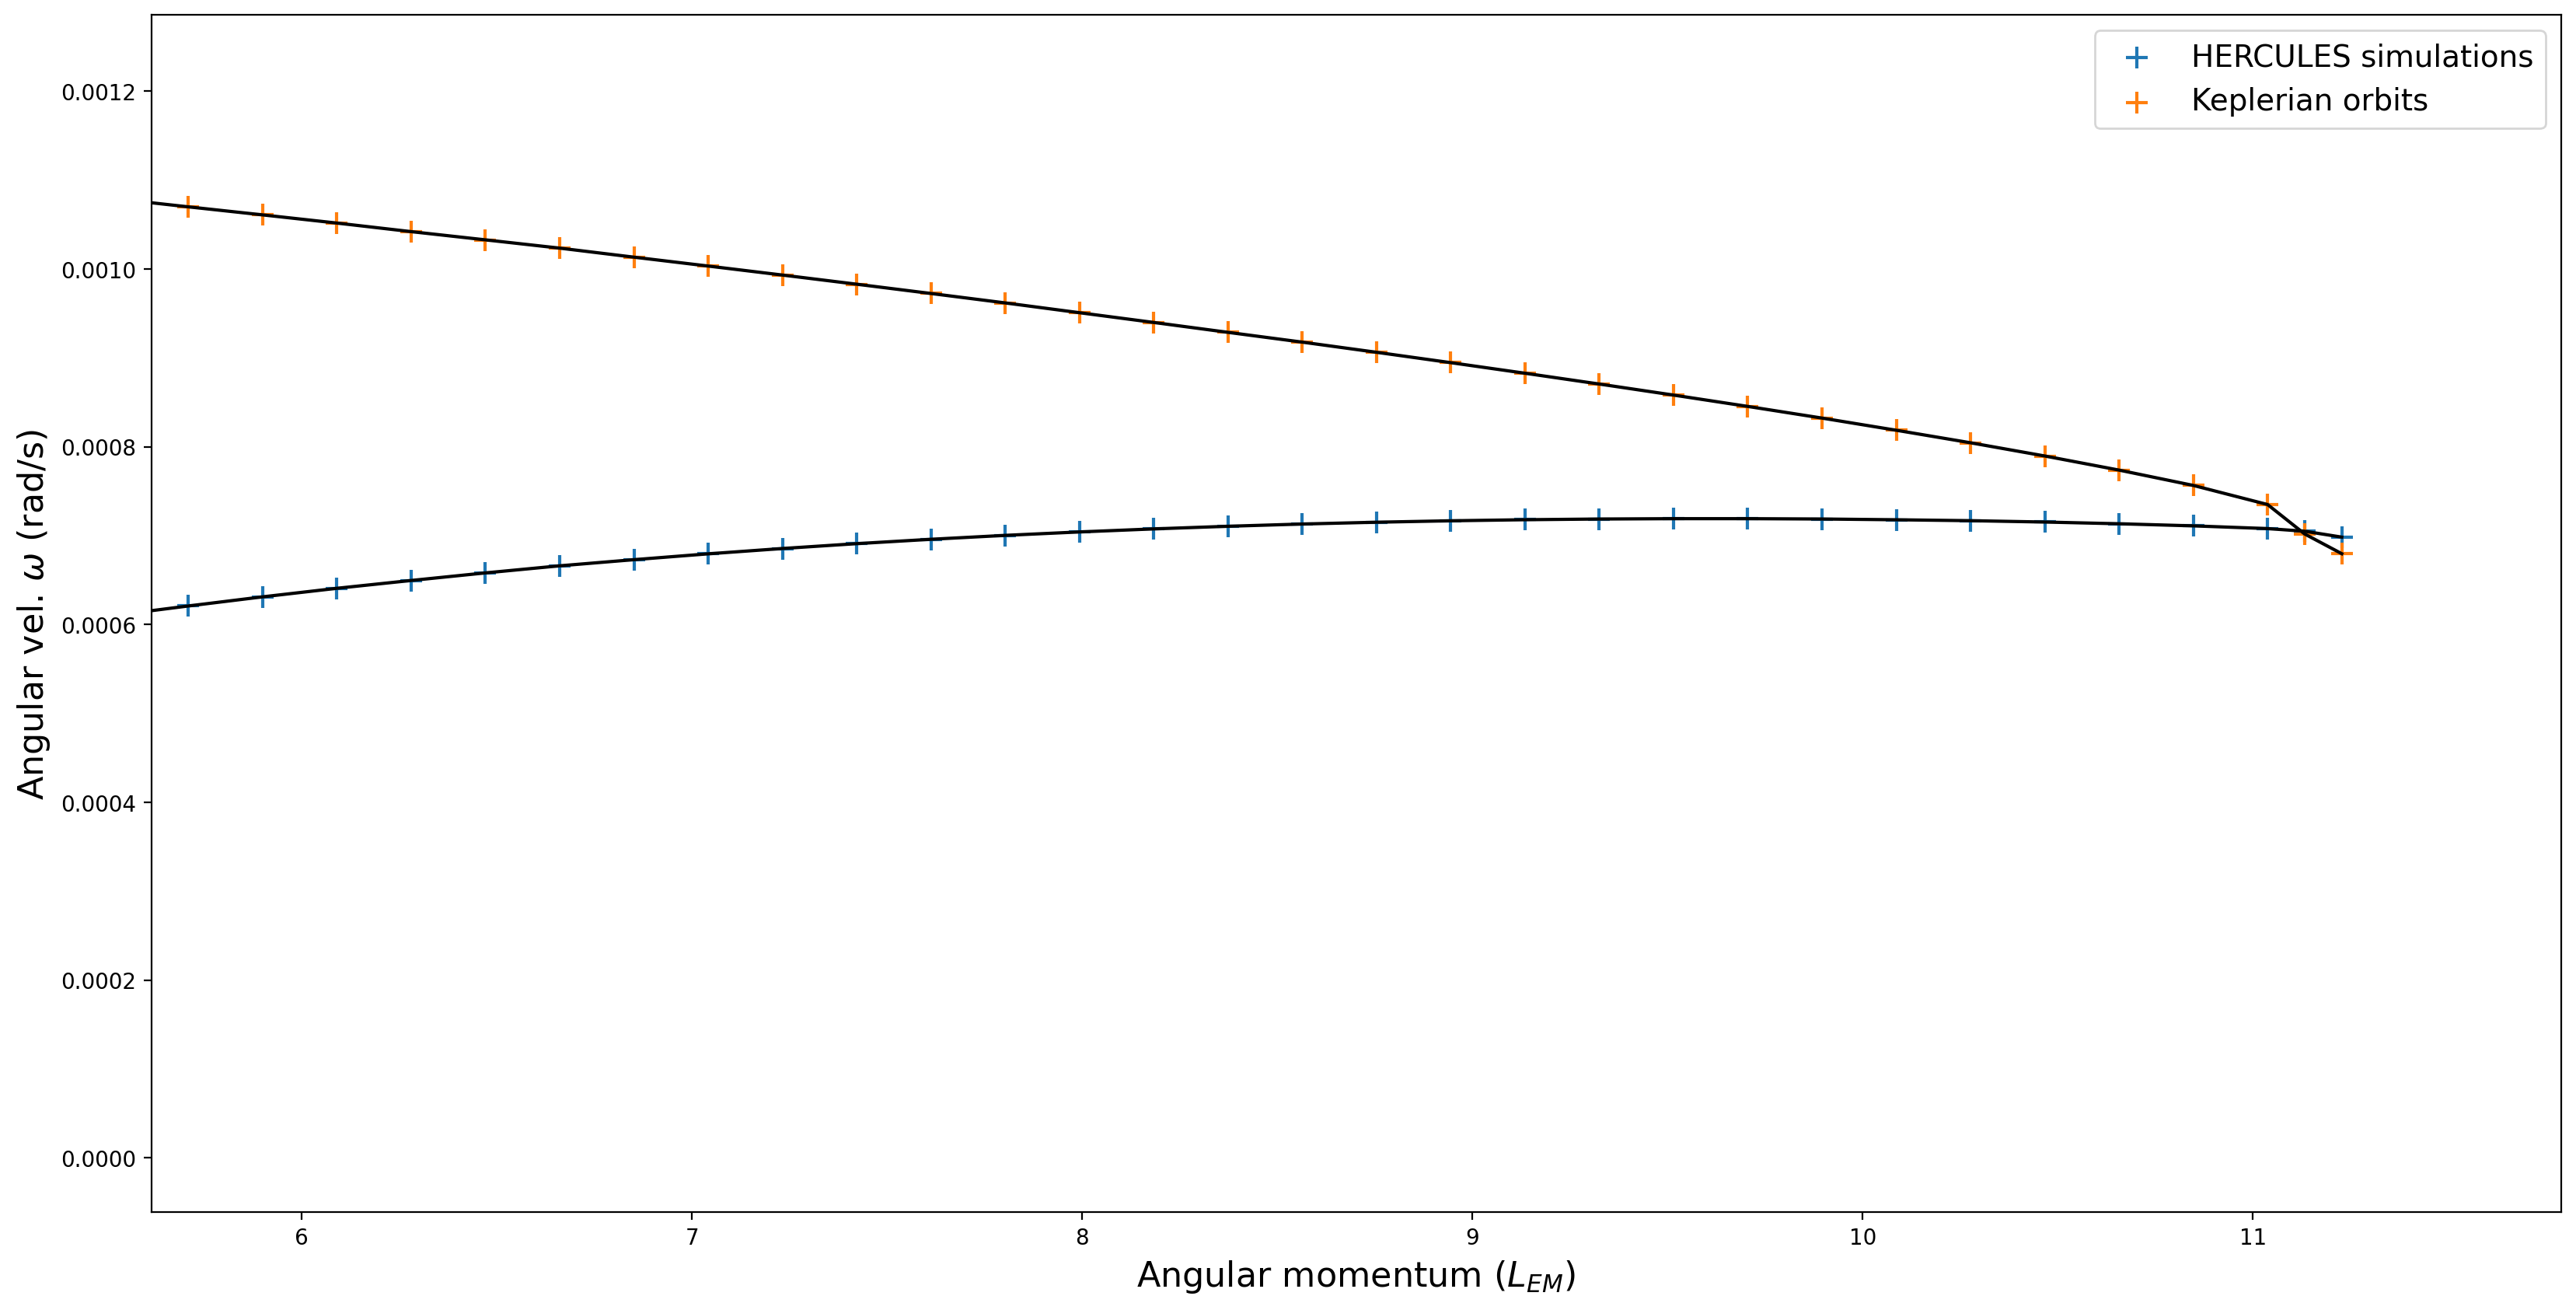

In [8]:
from scipy.optimize import brentq

key=hercdict[keylist[24]]
print(key.M/M_earth)
keparr=np.array([])

for i in range(np.size(key.Ltot)):
    #print(key.keys)
    p=key.planetdict[key.keys[i]]
    radius=np.empty(p.Nlayer)
    for k in np.arange(p.Nlayer):
        radius[k]=p.layers[k].a
    dVdr=gradient2(radius, p.Ulayers-(((radius*p.omega_rot)**2)/2.0))
    temp=np.sqrt(-1.0*dVdr/radius)
    keparr=np.append(keparr,temp[0])
    if i==np.size(key.Ltot)-1:
        #x=p.layers[0].xi*p.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6
        #plt.plot(radius,temp)
        #plt.show()
        core_layer=p.Nmaterial-1
        temp=np.where(p.flag_material==core_layer)[0]
        ind=temp[0]
        #ind=0
        ai=p.layers[ind].a
        a0=p.layers[0].a
        bi=p.layers[ind].a*p.layers[ind].xi[-1]
        b0=p.layers[0].a*p.layers[0].xi[-1]
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu,p.layers[ind].xi,label='CMB shell')
        plt.plot(p.layers[0].mu,p.layers[0].xi,label='Planet shell')
        plt.plot(p.layers[ind].mu,xi_ellipsoid(p.layers[ind].mu,ai,bi),label='CMB ellipsoid',ls='--')
        plt.plot(p.layers[0].mu,xi_ellipsoid(p.layers[0].mu,a0,b0),label='Planet ellipsoid',ls='--')
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\xi$',fontsize=16)
        plt.legend(fontsize=14)
        imname='muxi1'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu[1:],np.diff(p.layers[ind].xi))
        plt.plot(p.layers[0].mu[1:],np.diff(p.layers[0].xi))
        plt.plot(p.layers[ind].mu[1:],np.diff(xi_ellipsoid(p.layers[ind].mu,ai,bi)),ls='--')
        plt.plot(p.layers[0].mu[1:],np.diff(xi_ellipsoid(p.layers[0].mu,a0,b0)),ls='--')
        plt.plot(p.layers[ind].mu,np.zeros(np.size(p.layers[ind].mu)),color='k')
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\Delta\xi$',fontsize=16)
        imname='muxi2'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu[1:-1],np.diff(p.layers[ind].xi,n=2))
        plt.plot(p.layers[0].mu[1:-1],np.diff(p.layers[0].xi,n=2))
        plt.plot(p.layers[ind].mu[1:-1],np.diff(xi_ellipsoid(p.layers[ind].mu,ai,bi),n=2),ls='--')
        plt.plot(p.layers[0].mu[1:-1],np.diff(xi_ellipsoid(p.layers[0].mu,a0,b0),n=2),ls='--')
        plt.plot(p.layers[ind].mu,np.zeros(np.size(p.layers[ind].mu)),color='k')
        plt.ylim(2.5*np.diff(p.layers[ind].xi,n=2)[0],None)
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\Delta^2\xi$',fontsize=16)
        imname='muxi3'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()

hercinterp=interpolate.interp1d(key.Ltot/LEM,key.w)
kepinterp=interpolate.interp1d(key.Ltot/LEM,keparr)
def diffinterp(x): return kepinterp(x)-hercinterp(x)

found=False
jj=-1
while not found:
    try:
        intersect=brentq(diffinterp,0,key.Ltot[jj]/LEM)
        found=True
    except:
        jj-=1
        found=False
        if (jj*-1)>np.size(key.Ltot):
            found=True
            intersect=key.Ltot[-1]/LEM
            print('NOPE')
print(intersect,jj)
print('Maximum L seen:',key.Ltot[-1]/LEM)

#plt.scatter(intersect,hercinterp(intersect))
plt.plot(key.Ltot/LEM,key.w,c='k')
plt.scatter(key.Ltot/LEM,key.w,marker='+',s=100,label='HERCULES simulations')
#plt.scatter(key.Ltot/LEM,np.sqrt(G*key.M/key.r1**3))
plt.plot(key.Ltot/LEM,keparr,c='k')
plt.scatter(key.Ltot/LEM,keparr,marker='+',s=100,label='Keplerian orbits')

#plt.plot(key.Ltot/LEM,keparr-key.w)
#plt.plot(key.Ltot/LEM,np.zeros(np.size(key.Ltot)))
plt.xlim(0.5*np.amax(key.Ltot/LEM),None)
plt.ylim(None,None)
plt.ylabel('Angular vel. $\omega$ (rad/s)',fontsize=16)
plt.xlabel('Angular momentum ($L_{EM}$)',fontsize=16)
plt.legend(fontsize=14)
imname='corol_test'+'.pdf'
plt.savefig(imname,bbox_inches='tight')
plt.show()

In [9]:
Mcorols=np.array([0.001667078114325899,0.0033328373518183648,0.004999976776505257,0.010007283755274262,0.01668026595673431,
                 0.03332227848101266,0.050025178320273256,0.05499963281093027,0.08336844585091421,0.10006790670417252,
                 0.1517723913334673,0.16672166683410355,0.2166383263009845,0.25007144364074746,0.303408095572969,
                 0.43344730426629163,0.45499484461857875,0.5004180781595339,0.55041936909785,0.650453482687027,
                 0.7061969878105955,0.9101278849373786,1.298940668742884,1.4994135841537741,1.8989924820842543])

Lcorols=np.array([0.00012447033904915784,0.00039502183308535863,0.0007444225241437411,0.00240120174873789,0.005551311900630305,
                0.017157726045287394,0.03381365968505444,0.03836327694725919,0.0773205762982478,0.1050581915602321,
                0.20073137289397133,0.23918591990153856,0.3625849510797259,0.459228117865086,0.6238917541718889,
                1.1041937495542355,1.1886257061605843,1.3826165121697431,1.613592485882808,2.0929219937028063,
                2.3947487129564395,3.557411804014438,6.19806378501693,7.746299856523397,11.123254544900673])


In [95]:
with open('chosen_maxL.csv','w') as wfile:
    for i in range(np.size(Mcorols)):
        wfile.write('%.9e'%(Mcorols[i])+','+'%.9e'%(Lcorols[i])+'\n')

In [10]:
CoRoLinterp=interpolate.interp1d(Mcorols,Lcorols)

In [37]:
for keyname in keylist:
    outname=keyname+'_out.csv'
    key=hercdict[keyname]
    with open(outname,'w') as wfile:
        for i in range(np.size(key.Ltot)):
            if key.Ltot[i]/LEM<=CoRoLinterp(key.M/M_earth):
                wfile.write('%.9e'%(key.Ltot[i]/LEM)+','+'%.9e'%(key.PCMB[i]/1.e9)+'\n')

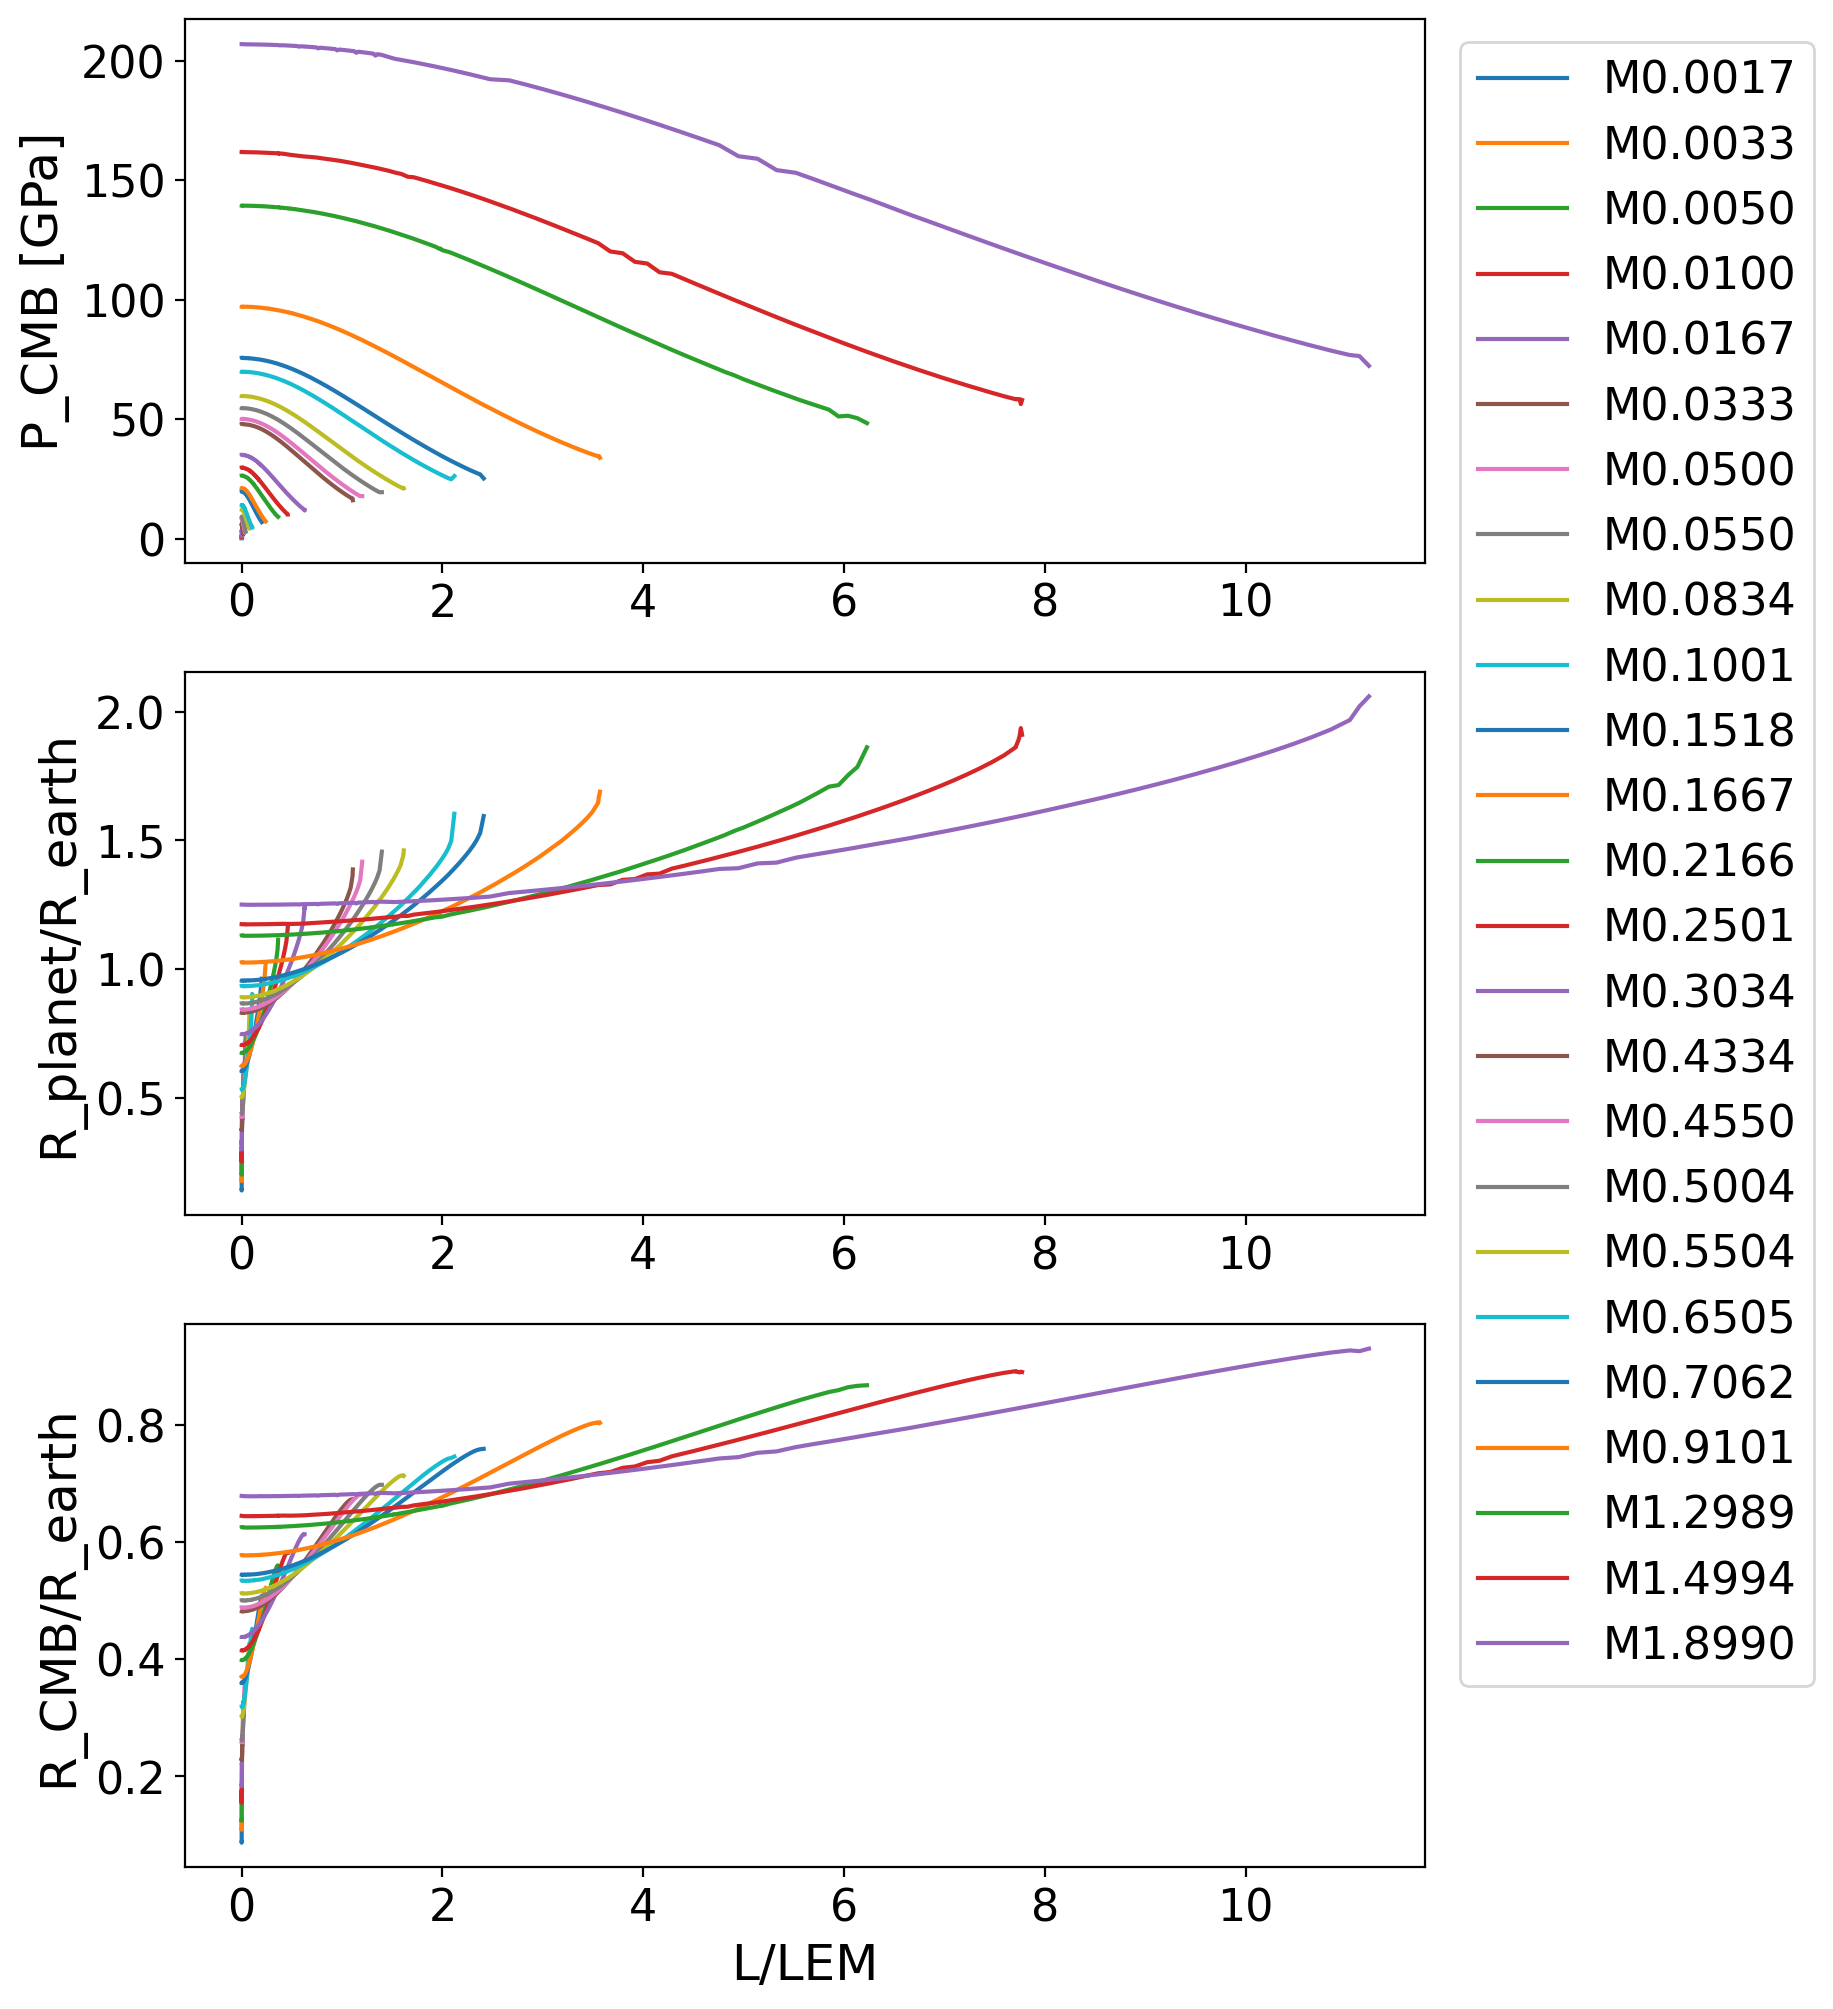

In [11]:
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16)

fig,ax=plt.subplots(3,1,figsize=[8,12])
for i in keylist:
    key=hercdict[i]
    label='M%.4f'%(key.M/M_earth)
    ax[0].plot(key.Ltot/LEM,key.PCMB/1.e9,label=label)
    ax[1].plot(key.Ltot/LEM,key.r1/R_earth)
    ax[2].plot(key.Ltot/LEM,key.rCMB/R_earth)

ax[0].legend(fontsize=16,bbox_to_anchor=(1.01, 1.0),)
ax[2].set_xlabel('L/LEM',size=18)
ax[0].set_ylabel('P_CMB [GPa]',size=18)
ax[1].set_ylabel('R_planet/R_earth',size=18)
ax[2].set_ylabel('R_CMB/R_earth',size=18)

plt.show()

0.0017$M_\oplus$ 0.31344805315058644
0.0033$M_\oplus$ 0.31254220002388217
0.0050$M_\oplus$ 0.3385477678902574
0.0100$M_\oplus$ 0.3291680797554339
0.0167$M_\oplus$ 0.3274032719475516
0.0333$M_\oplus$ 0.3364733848586786
0.0500$M_\oplus$ 0.336156633646503
0.0550$M_\oplus$ 0.3348369363541671
0.0834$M_\oplus$ 0.34403694562526566
0.1001$M_\oplus$ 0.34366406871279565
0.1518$M_\oplus$ 0.35491378434899107
0.1667$M_\oplus$ 0.34299104229163135
0.2166$M_\oplus$ 0.3488427655837085
0.2501$M_\oplus$ 0.3425013129732146
0.3034$M_\oplus$ 0.3420521211975196
0.4334$M_\oplus$ 0.3359876304749584
0.4550$M_\oplus$ 0.3561215526967207
0.5004$M_\oplus$ 0.3568260289405984
0.5504$M_\oplus$ 0.35309226868228283
0.6505$M_\oplus$ 0.3755391210284935
0.7062$M_\oplus$ 0.3338240691480665
0.9101$M_\oplus$ 0.34907980715058967
1.2989$M_\oplus$ 0.34713908306268554
1.4994$M_\oplus$ 0.3588321319183169
1.8990$M_\oplus$ 0.3497732302634513


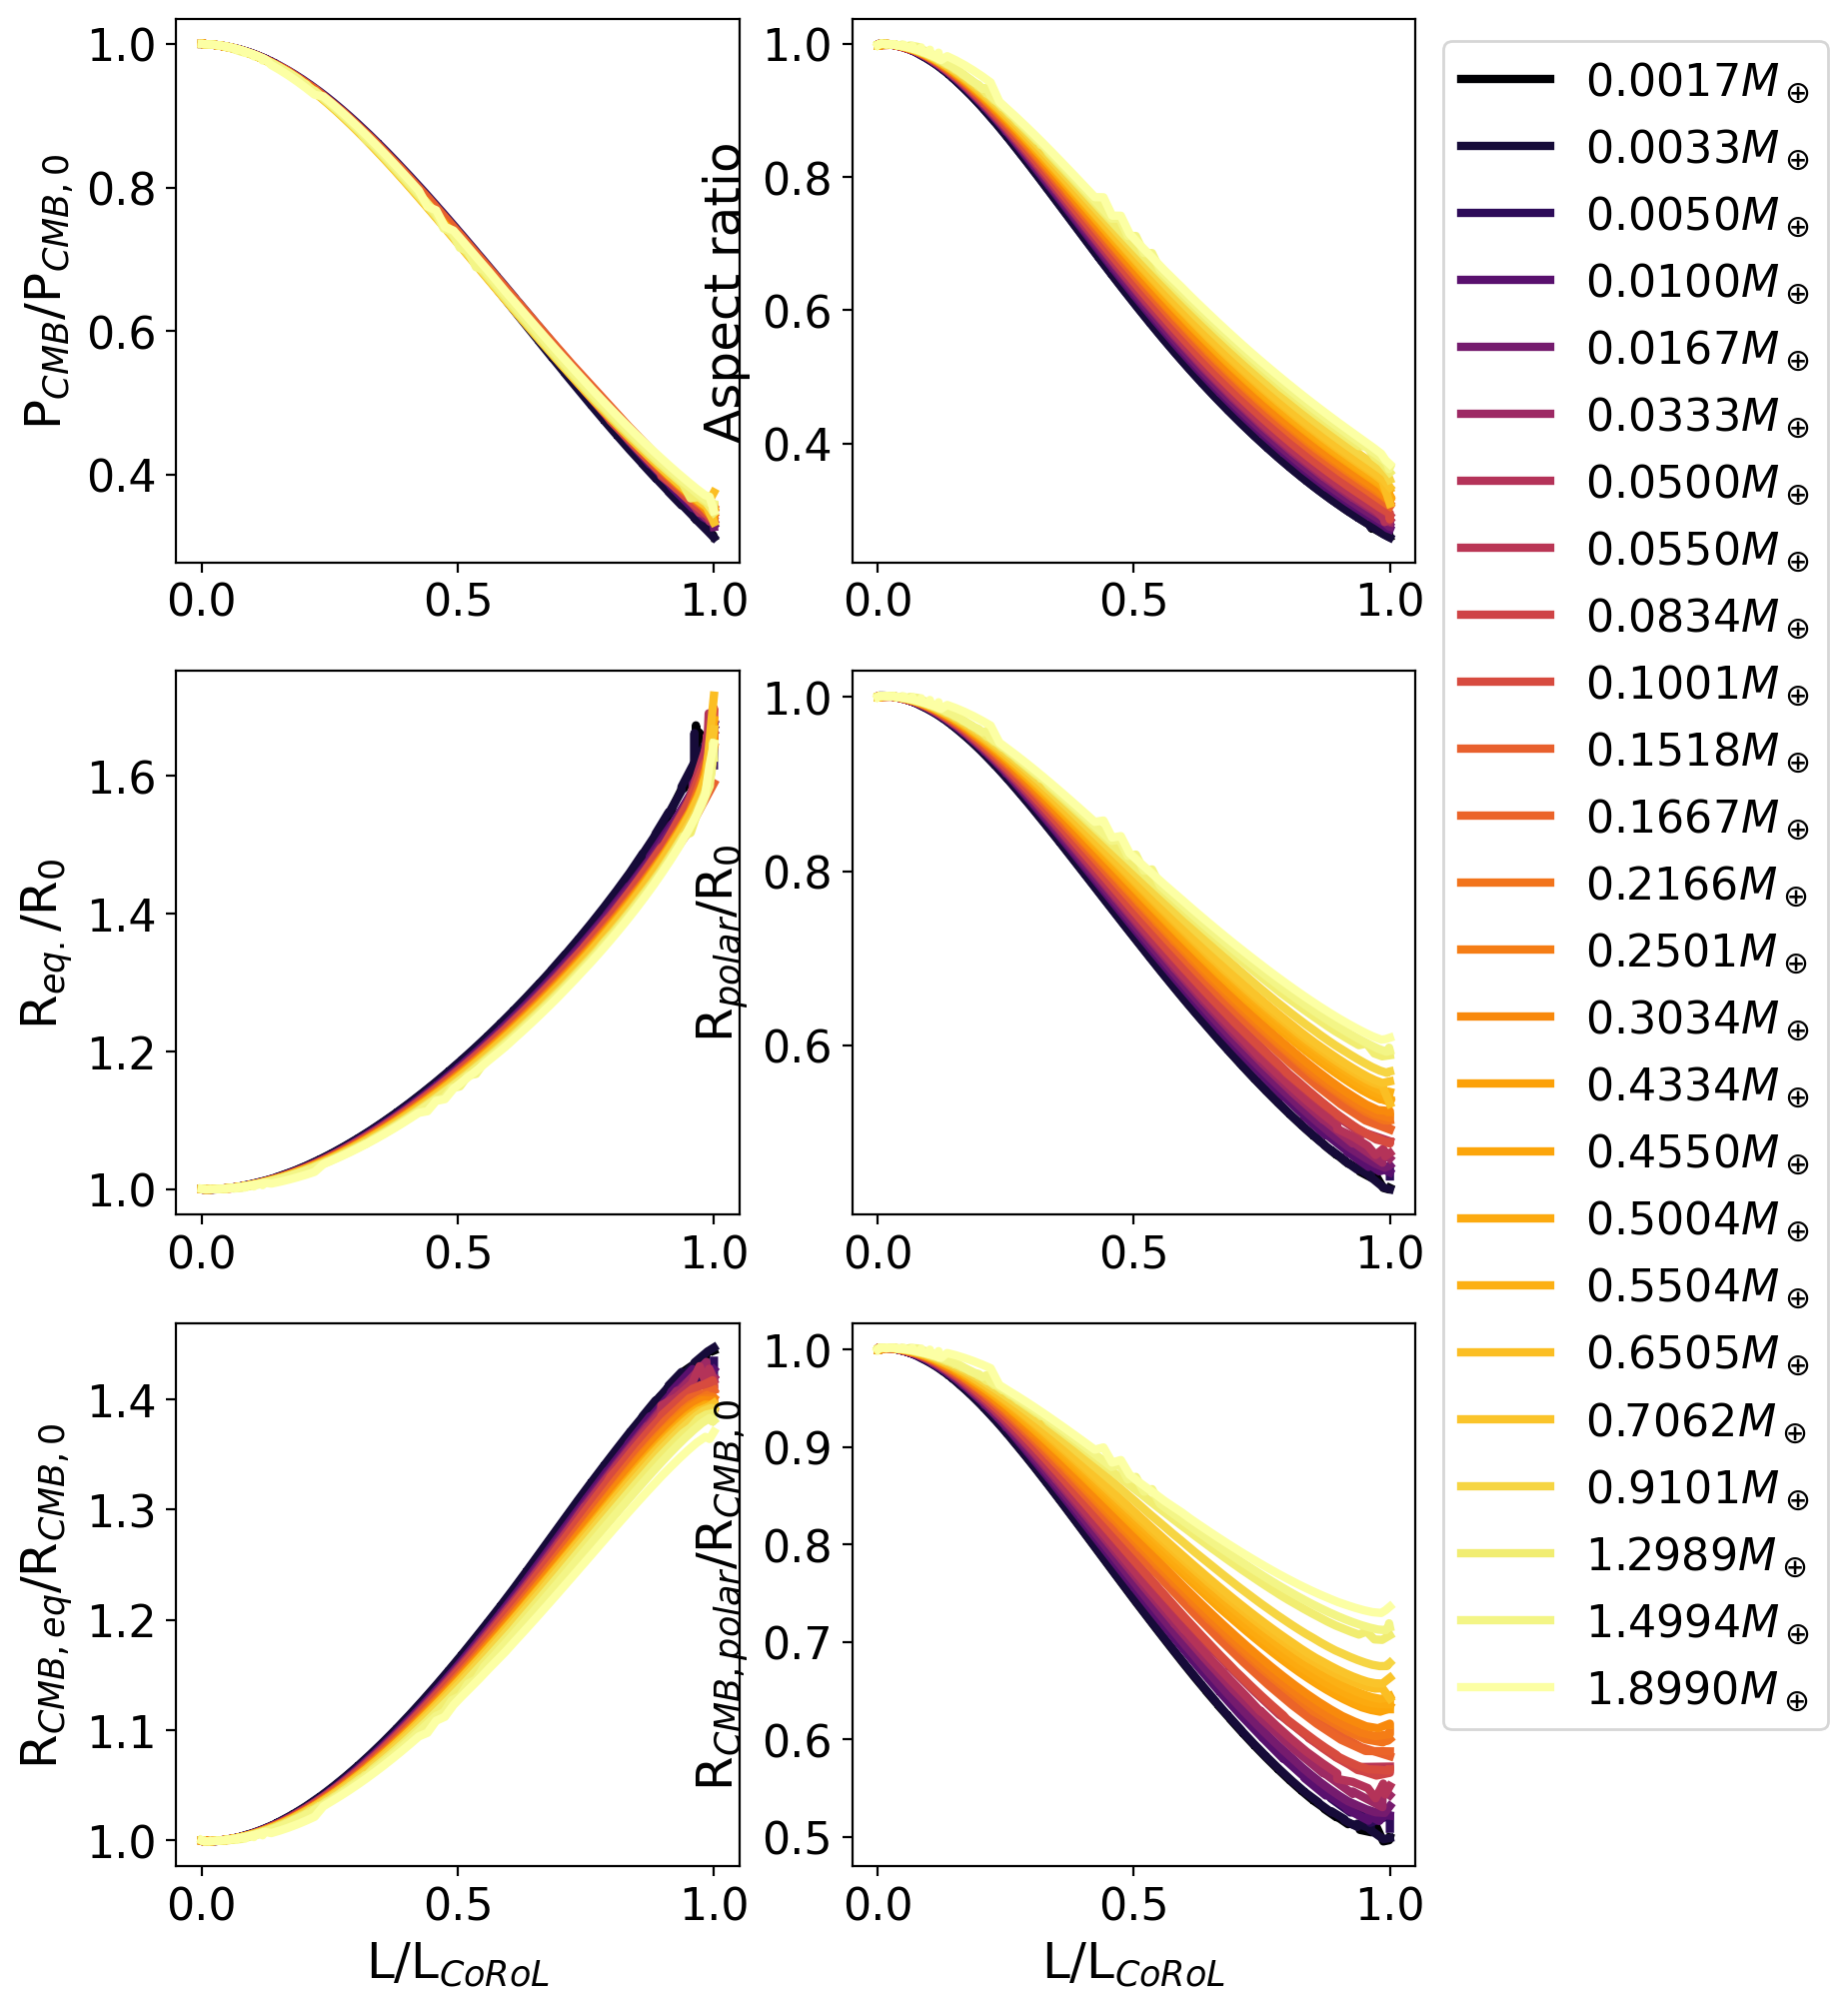

In [12]:
fig,ax=plt.subplots(3,2,figsize=[8,12])
norm=matplotlib.colors.LogNorm(vmin=hercdict[keylist[0]].M/M_earth,vmax=hercdict[keylist[-1]].M/M_earth)
cmap=matplotlib.colormaps['inferno']
for i in keylist:
    key=hercdict[i]
    label='%.4f$M_\oplus$'%(key.M/M_earth)
    print(label, key.PCMB[-1]/key.PCMB[0])
    #print(key.Ltot[-1])
    aspectarr=np.array([])
    eqarr=np.array([])
    CMBpolar=np.array([])
    polararr=np.array([])
    ind=np.where(key.planetdict[key.keys[0]].flag_material>0)[0][0]
    CMBpolar0=key.planetdict[key.keys[0]].layers[ind].b
    for j in range(np.size(key.Ltot)):
        ind=np.where(key.planetdict[key.keys[j]].flag_material>0)[0][0]
        eqarr=np.append(eqarr,key.planetdict[key.keys[j]].layers[0].a/key.planetdict[key.keys[0]].layers[0].a)
        aspectarr=np.append(aspectarr,key.planetdict[key.keys[j]].aspect)
        CMBpolar=np.append(CMBpolar,key.planetdict[key.keys[j]].layers[ind].b/CMBpolar0)
        polararr=np.append(polararr,key.planetdict[key.keys[j]].layers[0].b/key.planetdict[key.keys[0]].layers[0].b)
    
    ax[0,0].plot(key.Ltot/(key.Ltot[-1]),key.PCMB/key.PCMB[0],label=label,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[0,1].plot(key.Ltot/(key.Ltot[-1]),aspectarr,c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    #ax[1,0].plot(key.Ltot/(key.Ltot[-1]),key.r1/key.r1[0],c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    ax[1,0].plot(key.Ltot/(key.Ltot[-1]),eqarr,c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    #ax[1,1].plot(key.Ltot/(key.Ltot[-1]),key.b1/key.b1[0],c=cmap(norm(key.M/M_earth)),lw=3)
    ax[1,1].plot(key.Ltot/(key.Ltot[-1]),polararr,c=cmap(norm(key.M/M_earth)),lw=3)
    #ax[1,1].plot(key.Ltot/(key.Ltot[-1]),key.aspect,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[2,0].plot(key.Ltot/(key.Ltot[-1]),key.rCMB/key.rCMB[0],c=cmap(norm(key.M/M_earth)),lw=3)
    #ax[2,1].plot(key.Ltot/(key.Ltot[-1]),key.rCMB/key.bCMB,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[2,1].plot(key.Ltot/(key.Ltot[-1]),CMBpolar,c=cmap(norm(key.M/M_earth)),lw=3)
    
    

ax[0,1].legend(fontsize=16,bbox_to_anchor=(1.01, 1.0),)
ax[2,1].set_xlabel(r'L/L$_{CoRoL}$',size=18)
ax[2,0].set_xlabel(r'L/L$_{CoRoL}$',size=18)
ax[0,0].set_ylabel(r'P$_{CMB}$/P$_{CMB,0}$',size=18)
ax[0,1].set_ylabel(r'Aspect ratio',size=18)
ax[1,0].set_ylabel(r'R$_{eq.}$/R$_0$',size=18)
ax[1,1].set_ylabel(r'R$_{polar}$/R$_0$',size=18)
ax[2,0].set_ylabel(r'R$_{CMB,eq}$/R$_{CMB,0}$',size=18)
ax[2,1].set_ylabel(r'R$_{CMB,polar}$/R$_{CMB,0}$',size=18)

imname='all_HERC_new'+'.pdf'
plt.tight_layout()
plt.savefig(imname,dpi=200,bbox_inches='tight')
plt.show()

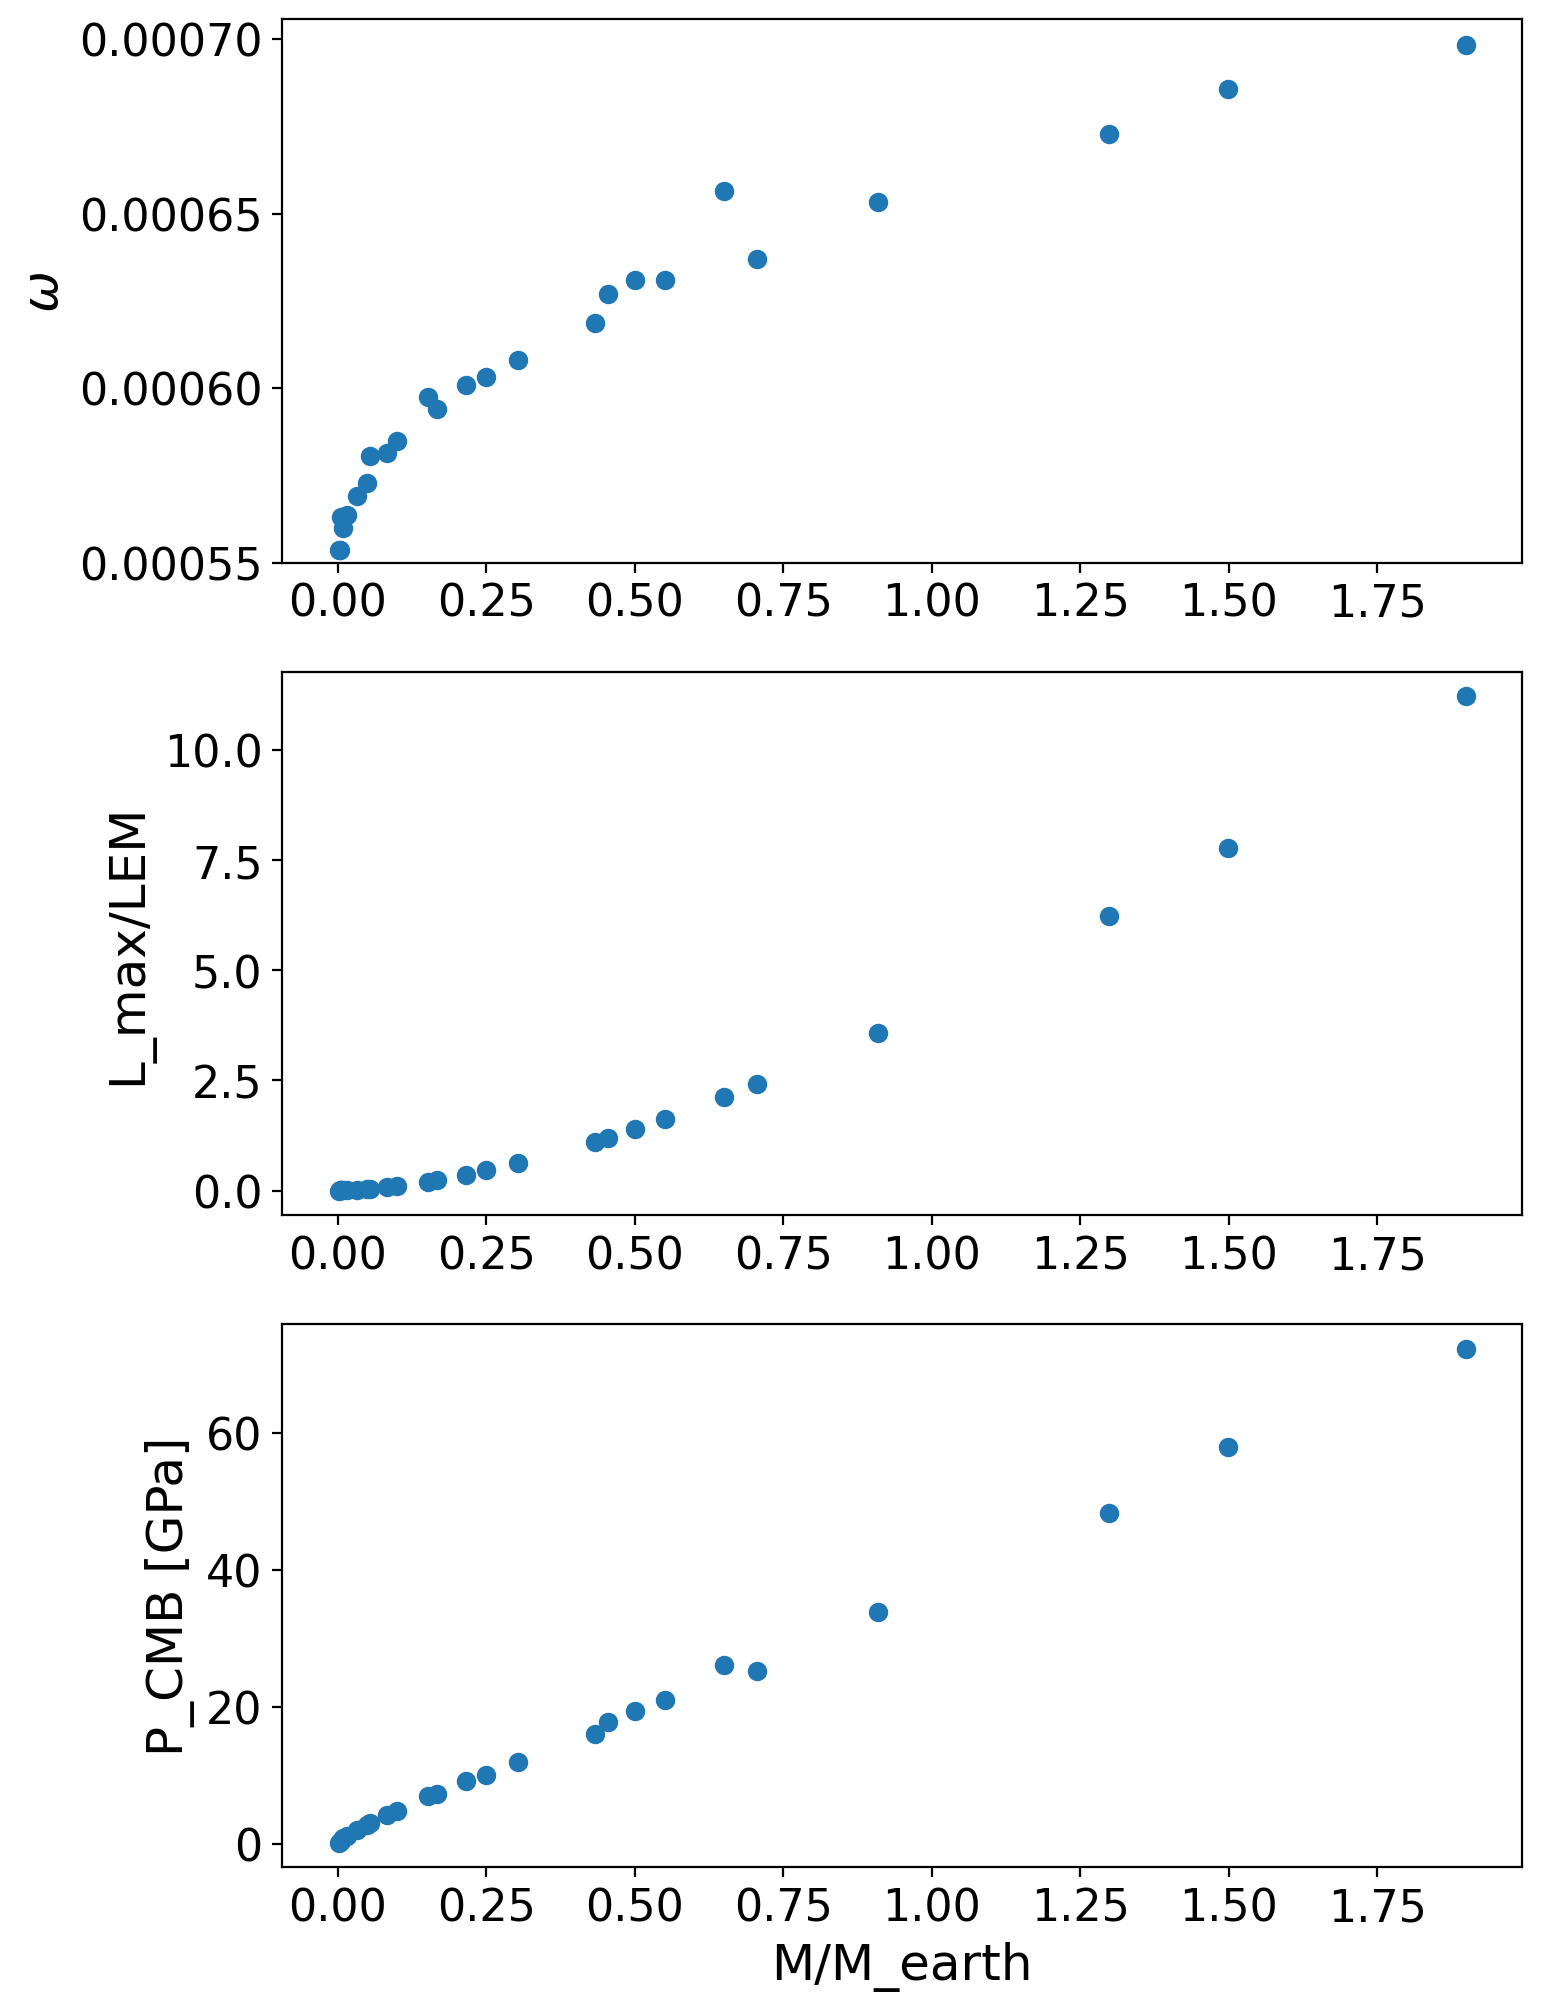

In [13]:
fig,ax=plt.subplots(3,1,figsize=[8,12])
ws=np.array([])
Ls=np.array([])
Ms=np.array([])
PCMBs=np.array([])
for i in keylist:
    key=hercdict[i]
    ws=np.append(ws,key.w[-1])
    Ls=np.append(Ls,key.Ltot[-1]/LEM)
    Ms=np.append(Ms,key.M/M_earth)
    PCMBs=np.append(PCMBs,key.PCMB[-1])
    
ax[0].scatter(Ms,ws)
ax[0].set_ylim(5.5e-4,None)
#ax[0].plot(Ms,ws)
ax[1].scatter(Ms,Ls)
#ax[1].plot(Ms,Ls)
ax[2].scatter(Ms,PCMBs/1.e9)
#ax[2].plot(Ms,PCMBs/1.e9)

#ax[0].legend(fontsize=16,bbox_to_anchor=(1.01, 1.0),)
ax[2].set_xlabel('M/M_earth',size=18)
ax[0].set_ylabel(r'$\omega$',size=18)
ax[1].set_ylabel('L_max/LEM',size=18)
ax[2].set_ylabel('P_CMB [GPa]',size=18)
for i in range(3):
    ax[i].set_xscale('linear')
    
with open('corol_L.csv','w') as wfile:
    for i in range(np.size(Ls)):
        wfile.write('%.9e'%(Ms[i])+','+'%.9e'%(Ls[i])+'\n')

plt.show()

In [14]:
cubfitdict=dict()
quartfitdict=dict()
for i in keylist:
    key=hercdict[i]
    coeffs=np.polyfit(key.Ltot/LEM,key.PCMB/1.e9,3)
    cubfitdict[i]=coeffs
    coeffs=np.polyfit(key.Ltot/LEM,key.PCMB/1.e9,4)
    quartfitdict[i]=coeffs

In [15]:
def plot_coeffs(testdict,hercdict=hercdict,keylist=keylist):
    fitsize=np.size(testdict[keylist[0]])
    print(fitsize)
    linflag=np.zeros(fitsize)
    fig,ax=plt.subplots(fitsize,1,figsize=[8,fitsize*3.75])
    for i in keylist:
        key=hercdict[i]
        for j in range(fitsize):
            ax[j].scatter(key.M/M_earth,testdict[i][j])
            if testdict[i][j]<0:
                linflag[j]=1
    ax[fitsize-1].set_xlabel('M/M_earth',size=18)
    for j in range(fitsize):
        ax[j].set_ylabel('k%d'%(fitsize-1-j),size=18)
        if linflag[j]==1:
            ax[j].set_yscale('symlog')
        else:
            ax[j].set_yscale('log')
    
    plt.show()
    
def write_coeffs(testdict,hercdict=hercdict,keylist=keylist):
    fitsize=np.size(testdict[keylist[0]])
    for j in range(fitsize):
        str1='fitdeg%d'%(fitsize-1)
        str2='_k%d'%(fitsize-1-j)
        fname=str1+str2
        with open(fname+'.csv','w') as wfile:
            for i in keylist:
                key=hercdict[i]
                wfile.write('%.9e'%(key.M/M_earth)+','+'%.9e'%np.log(np.abs(testdict[i][j]))+'\n')

4


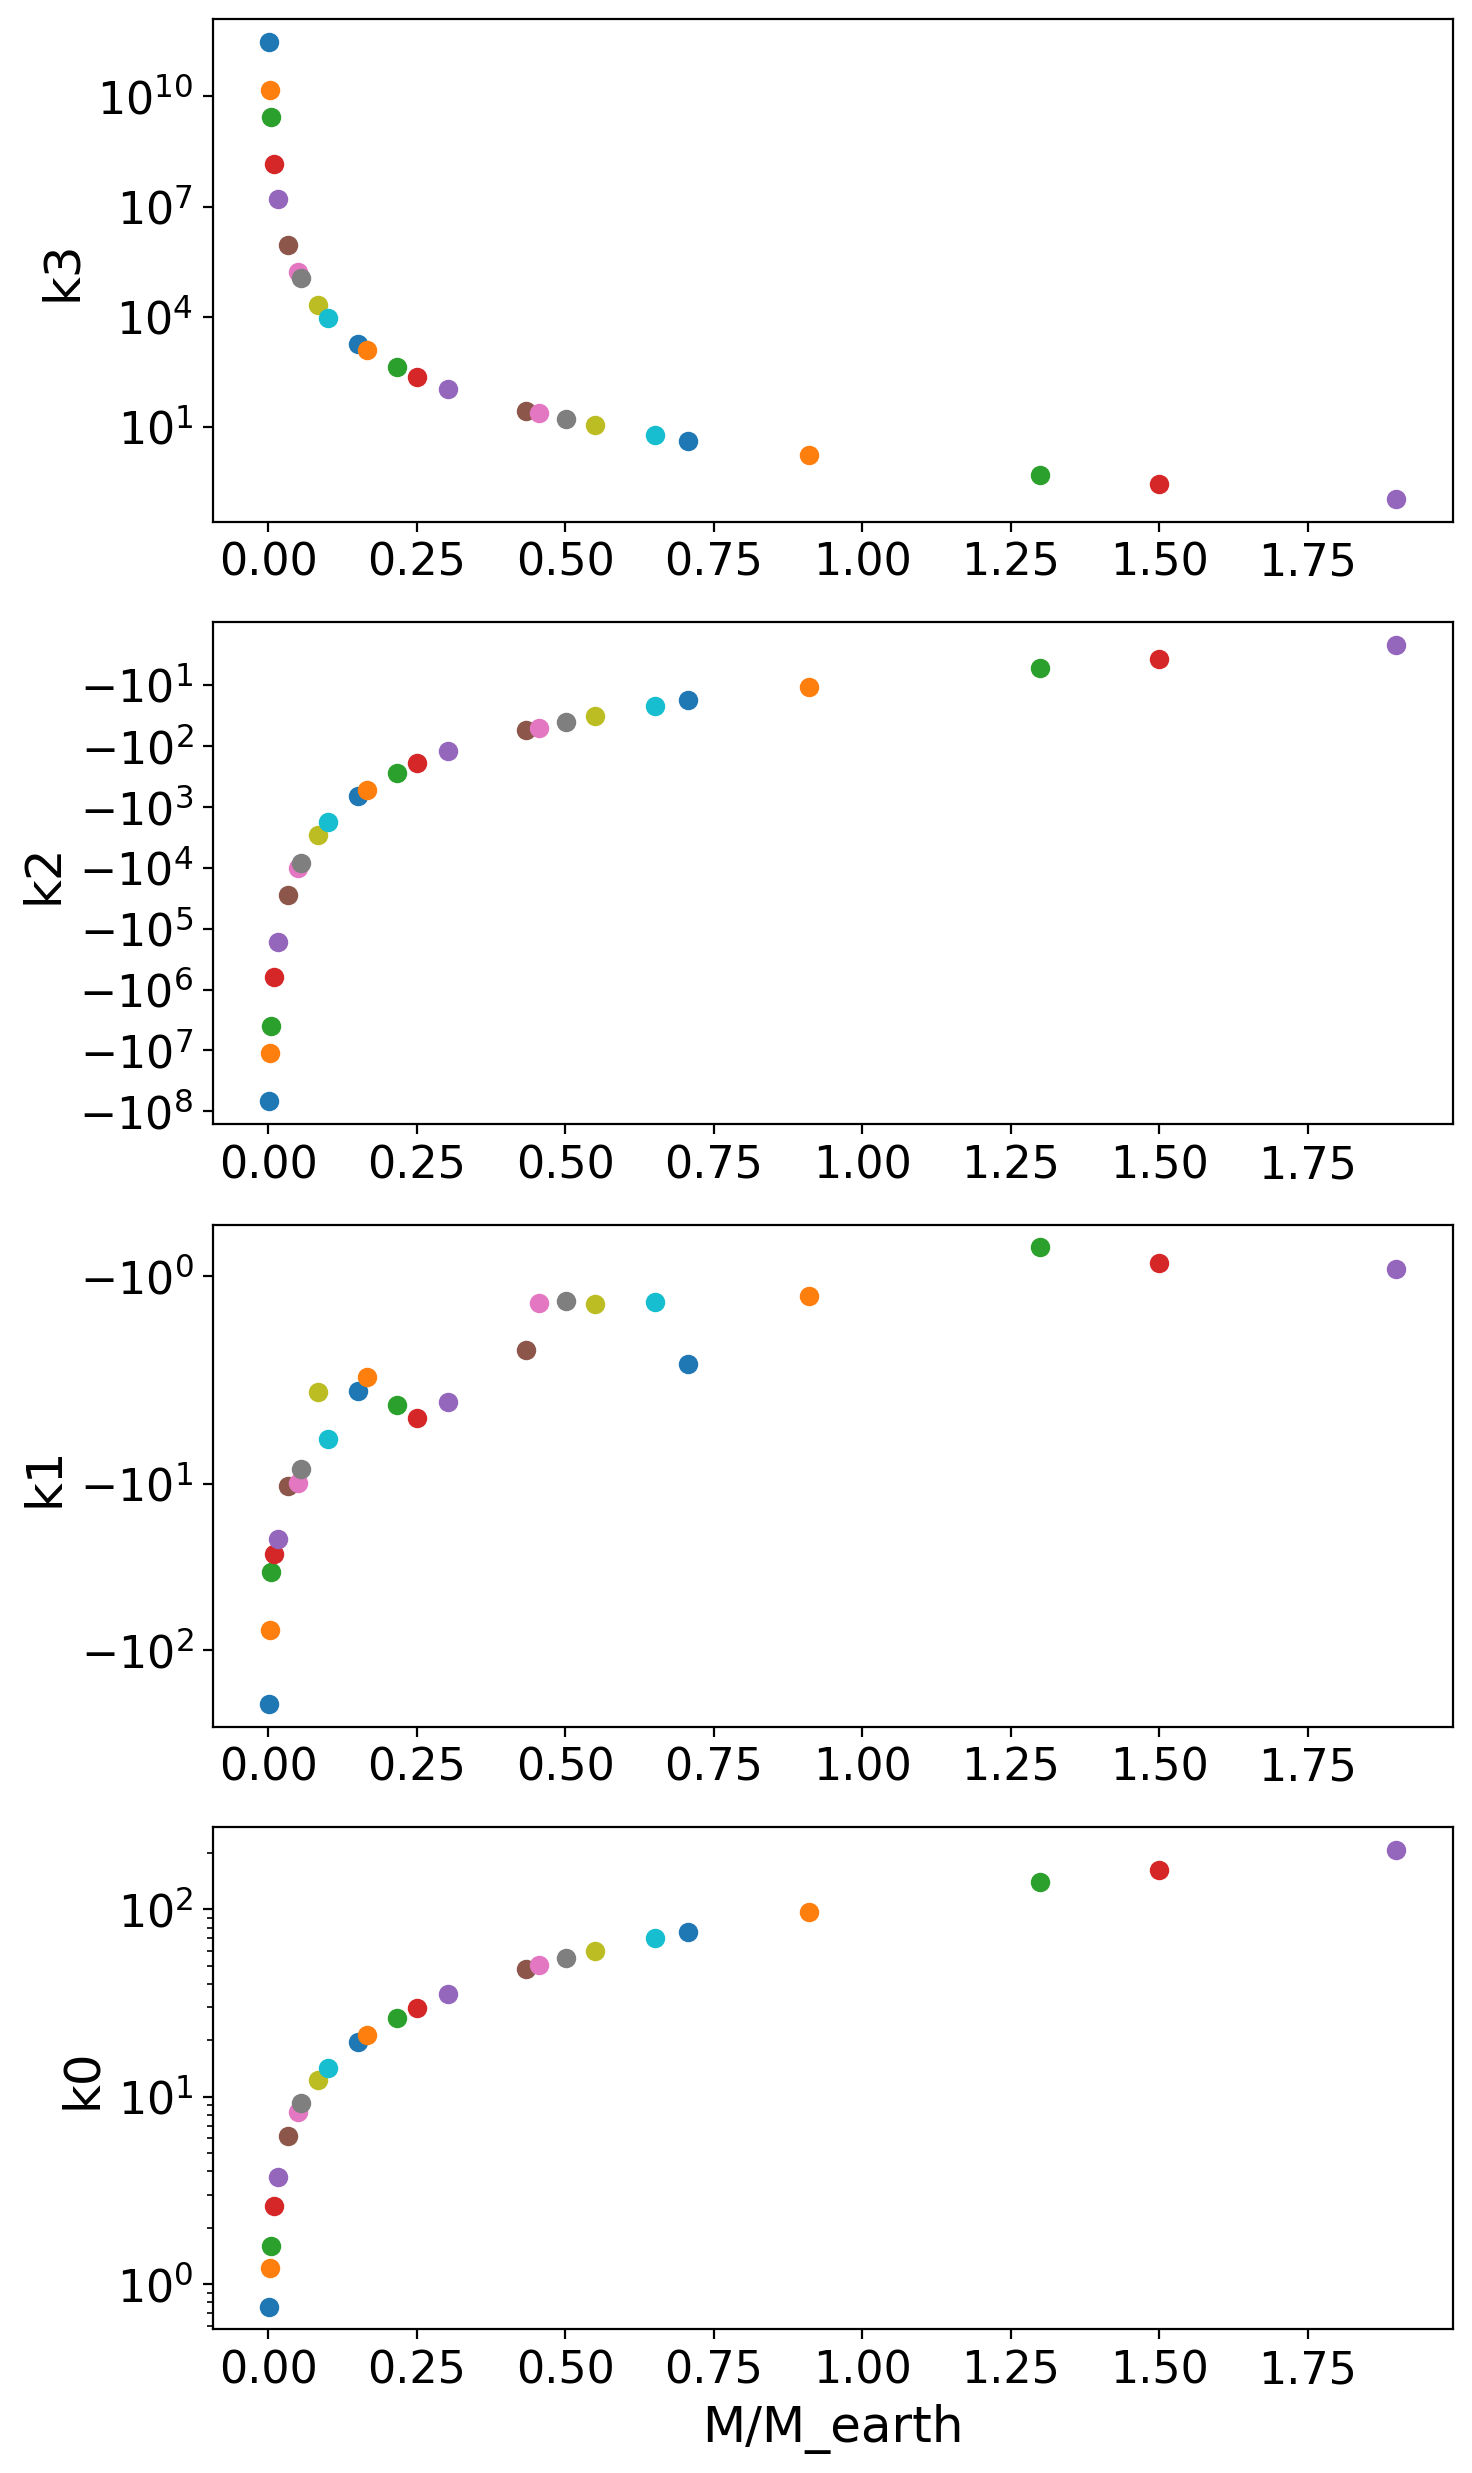

In [16]:
plot_coeffs(cubfitdict)
write_coeffs(cubfitdict)

5


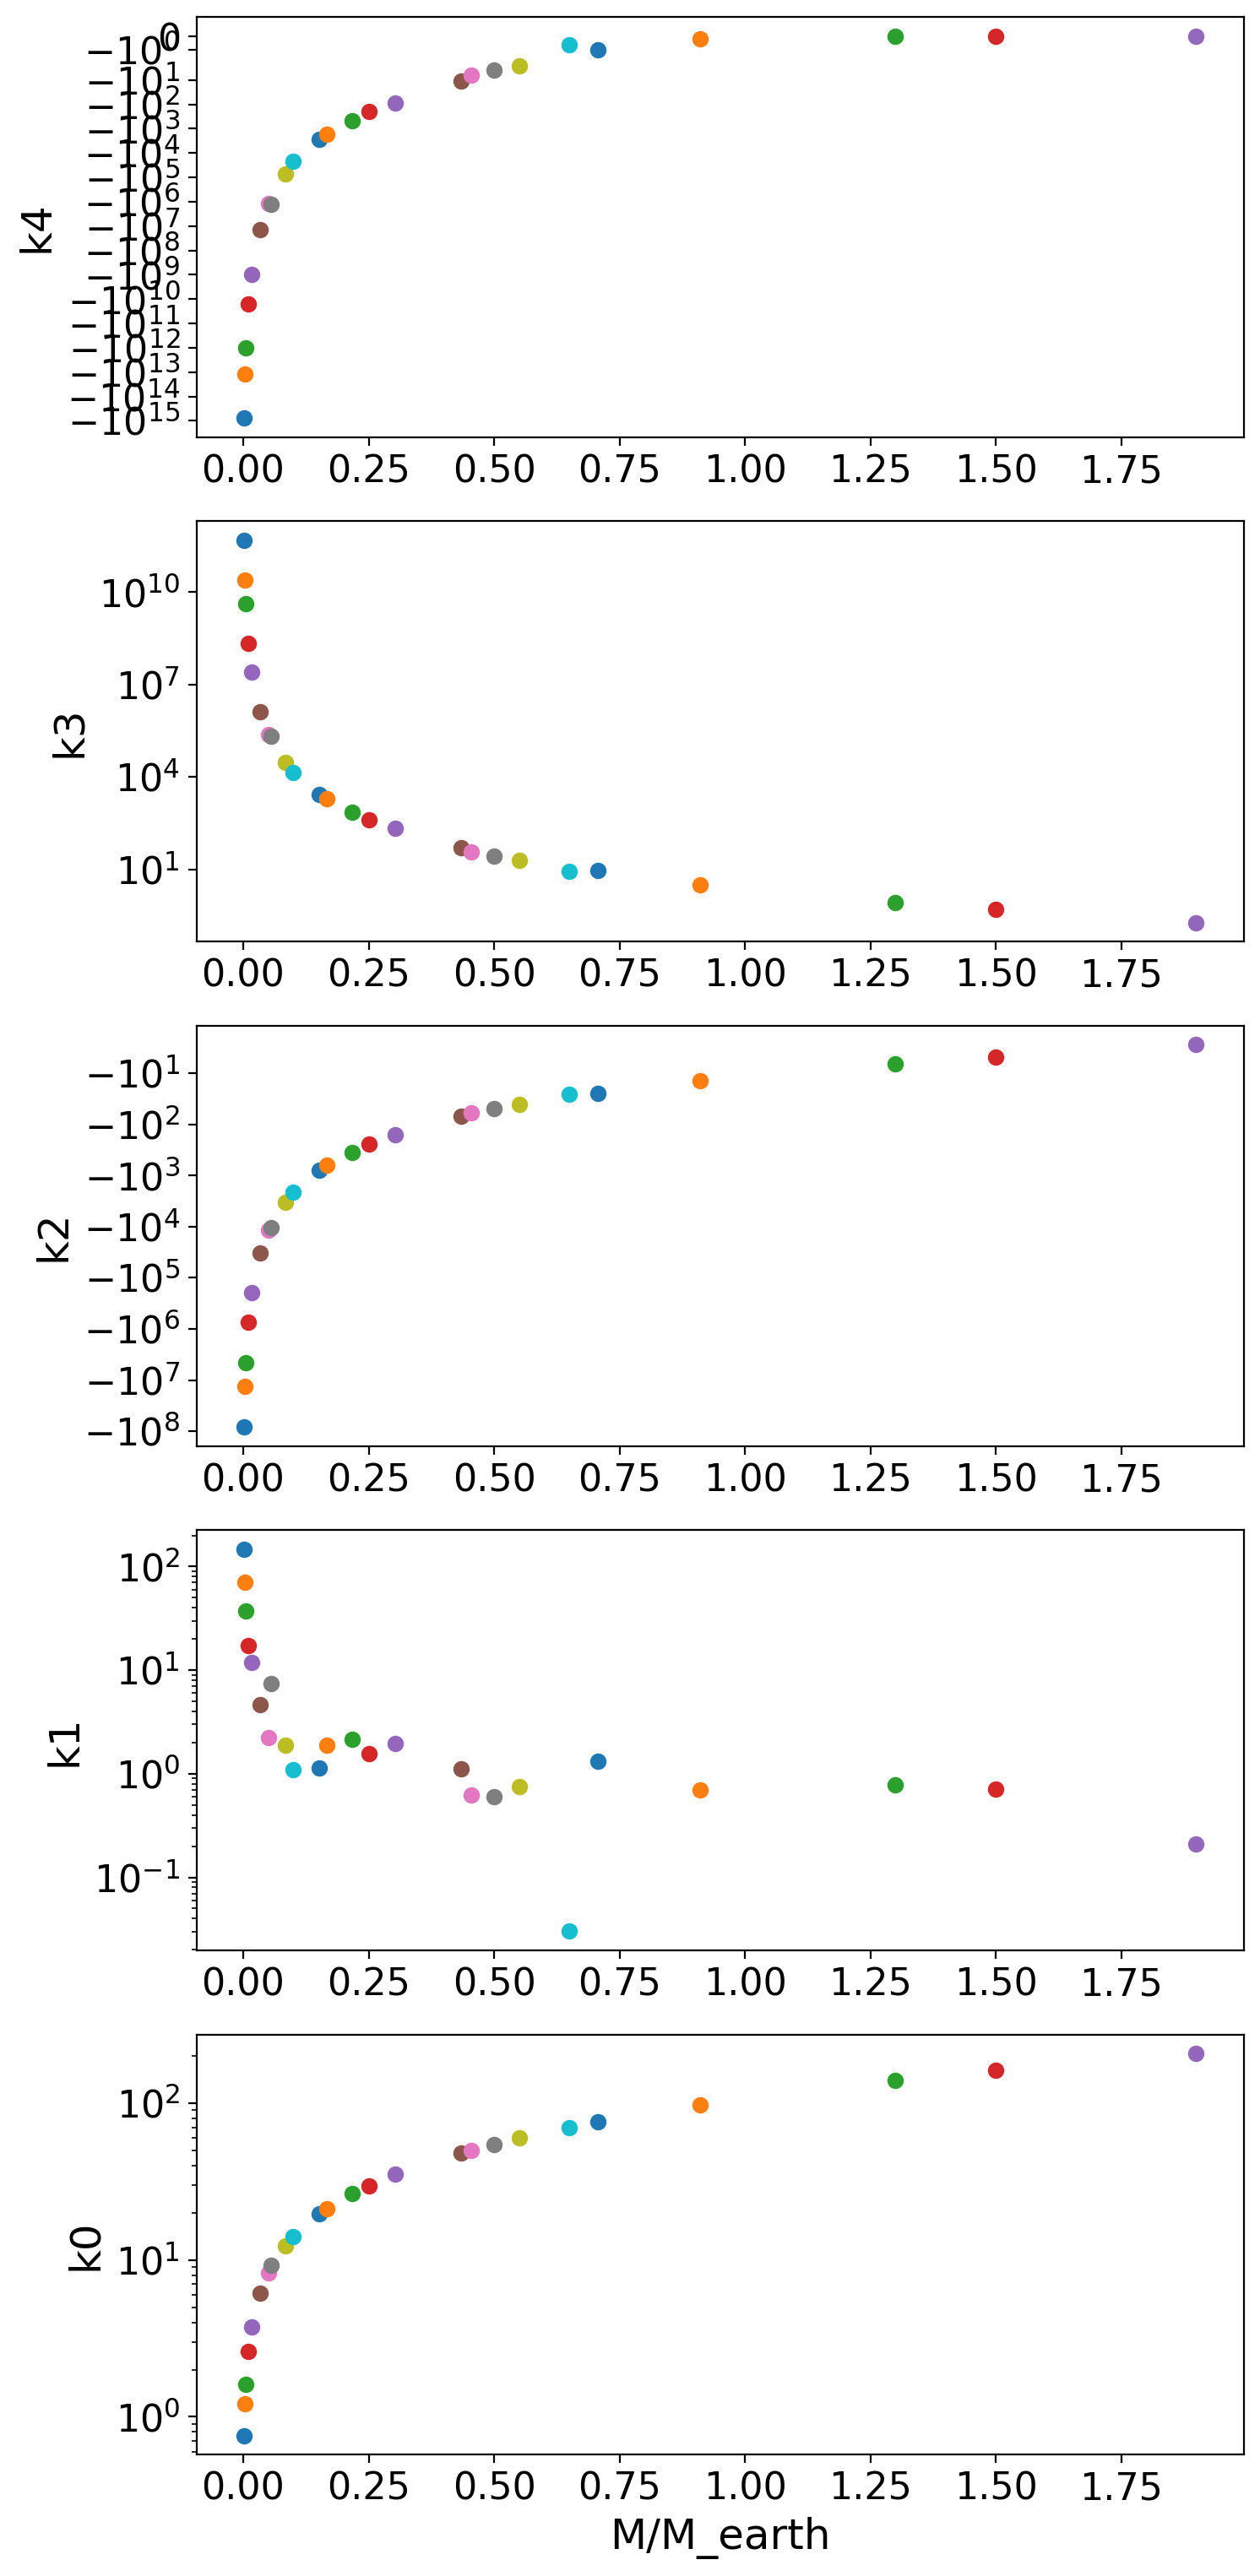

In [17]:
plot_coeffs(quartfitdict)

In [55]:
with open('alldataML'+'.csv','w') as wfile:
    for i in keylist:
        key=hercdict[i]
        for j in range(np.size(key.Ltot)):
            if key.Ltot[j]/LEM<CoRoLinterp(key.M/M_earth):
                wfile.write('%.9e'%(key.M/M_earth)+','+'%.9e'%(key.Ltot[j]/LEM)+','+'%.9e'%(key.PCMB[j]/1.e9)+'\n')

In [15]:
with open('LogalldataML'+'.csv','w') as wfile:
    for i in keylist:
        key=hercdict[i]
        for j in range(np.size(key.Ltot)):
            if key.Ltot[j]>0:
                wfile.write('%.9e'%(np.log(key.M/M_earth))+','+'%.9e'%(np.log(key.Ltot[j]/LEM))+','+'%.9e'%(np.log(key.PCMB[j]/1.e9))+'\n')

[7.72570542e-05 2.44558578e-04 4.80076413e-04 1.51858246e-03
 3.54121696e-03 1.11209487e-02 2.17308066e-02 2.53555260e-02
 5.03054052e-02 6.78766491e-02 1.34188281e-01 1.56512001e-01
 2.39904166e-01 3.03220751e-01 4.15762127e-01 7.42843462e-01
 8.04143569e-01 9.38596819e-01 1.09559134e+00 1.43596752e+00
 1.64114899e+00 2.47388329e+00 4.39567587e+00 5.53954377e+00
 8.10654117e+00]


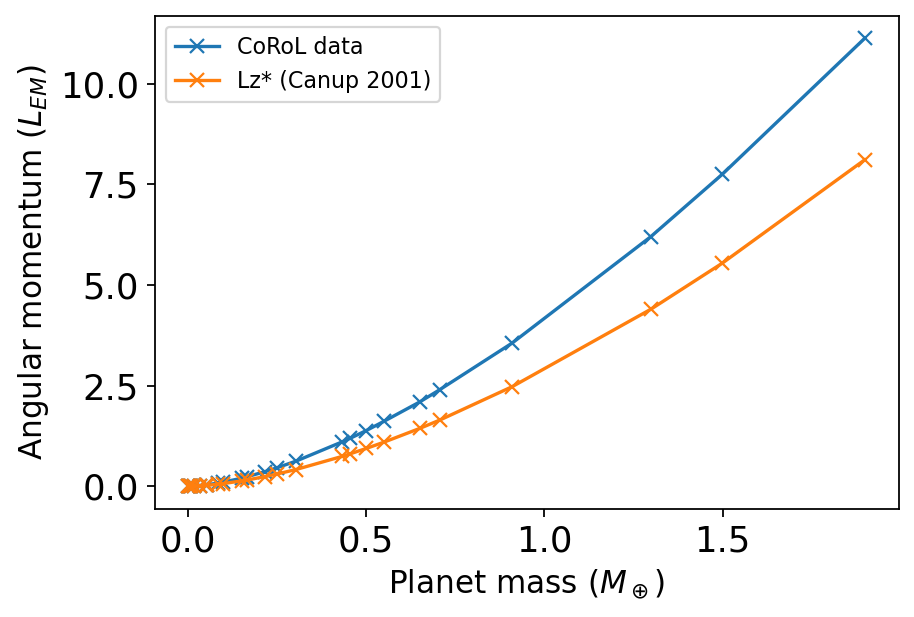

In [18]:
Lzstars=np.array([])

for i in keylist:
    #key=hercdict[i]
    planet=planetdict[i]
    Lzstars=np.append(Lzstars,planet.Lzstar)

print(Lzstars)
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(Mcorols,Lcorols,label='CoRoL data',marker='x')
plt.plot(Mcorols,Lzstars,label='Lz* (Canup 2001)',marker='x')
plt.legend()
plt.ylabel('Angular momentum ($L_{EM}$)',size=14)
plt.xlabel('Planet mass ($M_\oplus$)',size=14)
imname='CoRoL_Lz_compare'+'.pdf'
plt.savefig(imname,bbox_inches='tight')

[7.72570542e-05 2.44558578e-04 4.80076413e-04 1.51858246e-03
 3.54121696e-03 1.11209487e-02 2.17308066e-02 2.53555260e-02
 5.03054052e-02 6.78766491e-02 1.34188281e-01 1.56512001e-01
 2.39904166e-01 3.03220751e-01 4.15762127e-01 7.42843462e-01
 8.04143569e-01 9.38596819e-01 1.09559134e+00 1.43596752e+00
 1.64114899e+00 2.47388329e+00 4.39567587e+00 5.53954377e+00
 8.10654117e+00]


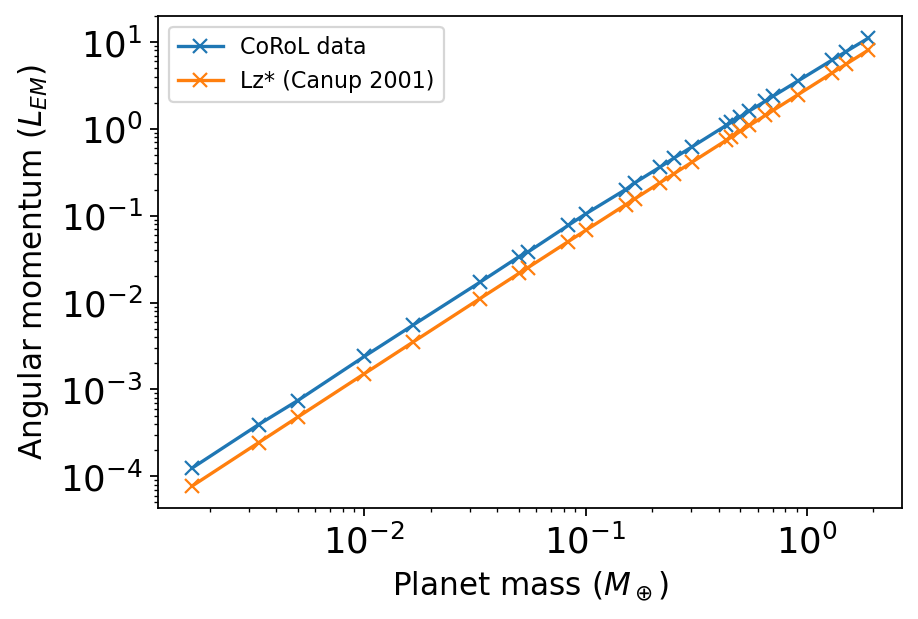

In [19]:
print(Lzstars)
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(Mcorols,Lcorols,label='CoRoL data',marker='x')
plt.plot(Mcorols,Lzstars,label='Lz* (Canup 2001)',marker='x')
plt.legend()
plt.ylabel('Angular momentum ($L_{EM}$)',size=14)
plt.xlabel('Planet mass ($M_\oplus$)',size=14)
plt.xscale('log')
plt.yscale('log')
imname='CoRoL_Lz_compare'+'.pdf'
#plt.savefig(imname,bbox_inches='tight')

[1.44056369e+37 2.54950288e+37 3.89747070e+37 5.46309335e+37
 7.13624170e+37 9.04154144e+37 1.11186184e+38 1.34249838e+38
 1.59070261e+38 1.85519896e+38 2.12075713e+38 2.41605910e+38
 2.72656057e+38 3.38290004e+38 3.72704256e+38]
[9.86025830e+33 1.75844879e+34 2.62202341e+34 2.86736525e+34
 4.12117958e+34 5.31969137e+34 7.65362454e+34 8.15306727e+34
 9.56719245e+34 1.08946559e+35 1.16211600e+35 1.89519703e+35
 1.30269005e+35 2.39640880e+35 1.91249048e+35]



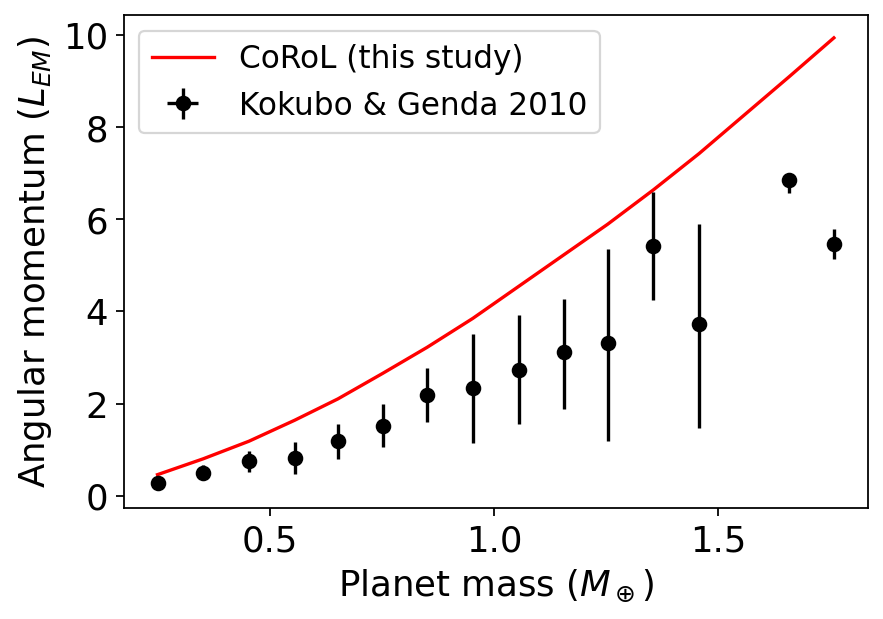

In [20]:
### CODE FROM SIMON FOR KOKUBO FIGURE
#read in KG10 file
file_KG10="./Figure3_KG2010_realistic_accretion.txt"
KG10_M,KG10_omg_mean,KG10_omg_low_error,KG10_omg_high_error=np.loadtxt(file_KG10,skiprows=1,unpack=True,delimiter=',')
#KG10_M#*=M_earth
KG10_omg_mean/=(60*60)
KG10_omg_low_error/=(60*60)
KG10_omg_high_error/=(60*60)

rhoc=3000.0
prefac=0.4*((3.0/(4.0*np.pi*rhoc))**(2.0/3.0))*((KG10_M*M_earth)**(5.0/3.0))
print(prefac)

    #KG10_M[i]=np.asarray(temp[i][0],dtype=np.float)*MEarth
    #KG10_omg_mean[i]=np.asarray(temp[i][1],dtype=np.float)/(60*60)
    #KG10_omg_low_error[i]=KG10_omg_mean[i]-(np.asarray(temp[i][2],dtype=np.float)/(60*60))
    #KG10_omg_high_error[i]=KG10_omg_mean[i]+(np.asarray(temp[i][3],dtype=np.float)/(60*60))

KG10_L_mean=prefac*KG10_omg_mean
KG10_L_low_error=prefac*KG10_omg_low_error
KG10_L_high_error=prefac*KG10_omg_high_error
print(KG10_L_mean)
print()

xerr=np.zeros([2,np.size(KG10_L_mean)])
yerr=np.zeros([2,np.size(KG10_L_mean)])
for i in range(np.size(KG10_L_mean)):
    yerr[0,i]=KG10_L_low_error[i]
    yerr[1,i]=KG10_L_high_error[i]
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(KG10_M,CoRoLinterp(KG10_M),color='red',label='CoRoL (this study)')

plt.errorbar(KG10_M,KG10_L_mean/LEM,yerr/LEM,xerr/LEM,fmt='o',color='k',label='Kokubo & Genda 2010')
plt.ylabel('Angular momentum ($L_{EM}$)',size=16)
plt.xlabel('Planet mass ($M_\oplus$)',size=16)
plt.gca().legend(fontsize=14)
#plt.ylim(None,4)
imname='CoRoL_genda'+'.pdf'
plt.savefig(imname,bbox_inches='tight')

[7.72570542e-05 2.44558578e-04 4.80076413e-04 1.51858246e-03
 3.54121696e-03 1.11209487e-02 2.17308066e-02 2.53555260e-02
 5.03054052e-02 6.78766491e-02 1.34188281e-01 1.56512001e-01
 2.39904166e-01 3.03220751e-01 4.15762127e-01 7.42843462e-01
 8.04143569e-01 9.38596819e-01 1.09559134e+00 1.43596752e+00
 1.64114899e+00 2.47388329e+00 4.39567587e+00 5.53954377e+00
 8.10654117e+00]


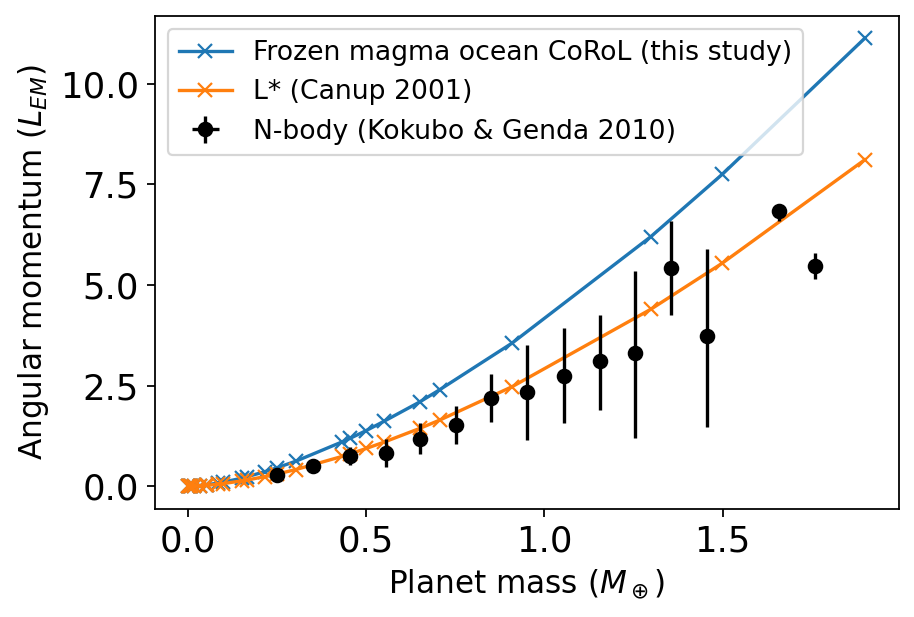

In [21]:
Lzstars=np.array([])

for i in keylist:
    #key=hercdict[i]
    planet=planetdict[i]
    Lzstars=np.append(Lzstars,planet.Lzstar)

print(Lzstars)
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(Mcorols,Lcorols,label='Frozen magma ocean CoRoL (this study)',marker='x')
plt.plot(Mcorols,Lzstars,label='L* (Canup 2001)',marker='x')
plt.errorbar(KG10_M,KG10_L_mean/LEM,yerr/LEM,xerr/LEM,fmt='o',color='k',label='N-body (Kokubo & Genda 2010)')
plt.legend(fontsize=12)
plt.ylabel('Angular momentum ($L_{EM}$)',size=14)
plt.xlabel('Planet mass ($M_\oplus$)',size=14)
imname='CoRoL_lstar_kokubo'+'.pdf'
plt.savefig(imname,bbox_inches='tight')

In [22]:
class simdata_abbr(object):
    def __init__(self,Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label):
        self.Lzbnd=Lzbnd
        self.Mbound=Mbound
        self.Lztot=Lztot
        self.M_t=M_t
        self.M_i=M_i
        self.Lzstarstandard=Lzstarstandard
        self.Lzstar=Lzstar
        self.synflag=synflag
        self.QS=QS
        self.thetamarker=thetamarker
        self.sizemarker=sizemarker
        self.ratiomarker=ratiomarker
        self.outcomemarker=outcomemarker
        self.QstarS=QstarS
        self.label=label

#temp=np.loadtxt('Postema_accretionlistno0.csv',unpack=True,delimiter=',')      
[Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label,temp]=np.loadtxt('Postema_accretionlistno0.csv',unpack=True,delimiter=',',dtype={'names':('Lzbnd','Mbound','Lztot','M_t','M_i','Lzstarstandard','Lzstar','synflag','QS','thetamarker','sizemarker','ratiomarker','outcomemarker','QstarS','label','nan'),'formats':('float64','float64','float64','float64','float64','float64','float64','float64','float64','<U8','<U8','<U8','<U8','float64','<U8','str')})
#print(sizemarker)
accretionlistno0=[] 
for i in range(np.size(Lzbnd)):
    accretionlistno0=np.append(accretionlistno0,simdata_abbr(Lzbnd[i],Mbound[i],Lztot[i],M_t[i],M_i[i],Lzstarstandard[i],Lzstar[i],synflag[i],QS[i],thetamarker[i],sizemarker[i],ratiomarker[i],outcomemarker[i],QstarS[i],label[i]))

[Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label,temp]=np.loadtxt('Postema_hitandrunlist.csv',unpack=True,delimiter=',',dtype={'names':('Lzbnd','Mbound','Lztot','M_t','M_i','Lzstarstandard','Lzstar','synflag','QS','thetamarker','sizemarker','ratiomarker','outcomemarker','QstarS','label','nan'),'formats':('float64','float64','float64','float64','float64','float64','float64','float64','float64','<U8','<U8','<U8','<U8','float64','<U8','str')})
#print(sizemarker)
hitandrunlist=[] 
for i in range(np.size(Lzbnd)):
    hitandrunlist=np.append(hitandrunlist,simdata_abbr(Lzbnd[i],Mbound[i],Lztot[i],M_t[i],M_i[i],Lzstarstandard[i],Lzstar[i],synflag[i],QS[i],thetamarker[i],sizemarker[i],ratiomarker[i],outcomemarker[i],QstarS[i],label[i]))

In [23]:
def corot(M):
    #return -0.00542195+4.13819*M**(1.57064)
    #return -0.00820213+4.13928*M**(1.55824)
    #return 4.12726*M**(1.56218)
    #return np.exp(1.51712-0.08747*M+1.64044*np.log(M))
    return np.exp(1.33045+0.221544*np.exp(-M)+1.64827*np.log(M))

In [24]:
## HISTOGRAM
def COROL_hist(simlistlist,ax=None,labels=None,xlim=None,star=False,loglog=False,legend=True,colors=None,Lzstar=False,title=None,savefig=None,corolfn=corot,L0=False,bins=10,combined=False):
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    if ax is None: 
        fig,ax=plt.subplots(1,1,figsize=(8,5))
        axset=True
    else: axset=False
    count=0
    allLz=np.array([])
    allLz0=np.array([])
    allLzstar=np.array([])
    #print(simlistlist)
    print(len(simlistlist))
    for i in range(len(simlistlist)):
        simlist = simlistlist[i]
        for j in range(np.size(simlist)):
            sim=simlist[j]  
            allLz=np.append(allLz,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
            allLz0=np.append(allLz0,np.amax(sim.Lztot)/np.amax([corolfn(sim.M_t+sim.M_i)]))
            allLzstar=np.append(allLz,sim.Lzbnd/sim.Lzstarstandard)
    if Lzstar==True: histarr=allLzstar
    if L0==True: histarr=allLz0
    else: histarr=allLz
    flabel=None
    if combined:
         flabel='$L_{bnd}$'

    if combined:
        counts2,bins2 = np.histogram(allLz0,bins=bins,density=False,)
        ax.stairs(counts2/np.size(allLz0),bins2,fill=True,label='$L_{0}$')
        
    counts1,bins1 = np.histogram(histarr,bins=bins,density=False)
    print(counts1/np.size(histarr),bins1)
    print('Median:',np.median(histarr))
    ax.stairs(counts1/np.size(histarr),bins1,fill=True,label=flabel)
    if combined:
        ax.stairs(counts2/np.size(allLz0),bins2,fill=False,color='tab:blue')
    if Lzstar: ax.set_xlabel('$L_Z/L_*$',size=16)
    if L0: ax.set_xlabel('$L_{Z,0}/L_{CoRoL}$',size=16)
    else:ax.set_xlabel(r'$L/L_\text{CoRoL}^\text{cond}$',size=16)
    ax.set_ylabel('Population fraction',size=16)
    if combined:
        ax.legend(fontsize=16)
    if title is not None:
        ax.set_title(title,size=16)
    if axset:
        if savefig is not None:
            imname=savefig+'.pdf'
            plt.savefig(imname,bbox_inches='tight')
        plt.show()

1
[0.         0.         0.02608696 0.02608696 0.13043478 0.12173913
 0.13043478 0.06956522 0.10434783 0.11304348 0.03478261 0.07826087
 0.06956522 0.04347826 0.05217391 0.         0.         0.
 0.         0.         0.         0.         0.         0.        ] [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2 ]
Median: 0.396644812154222


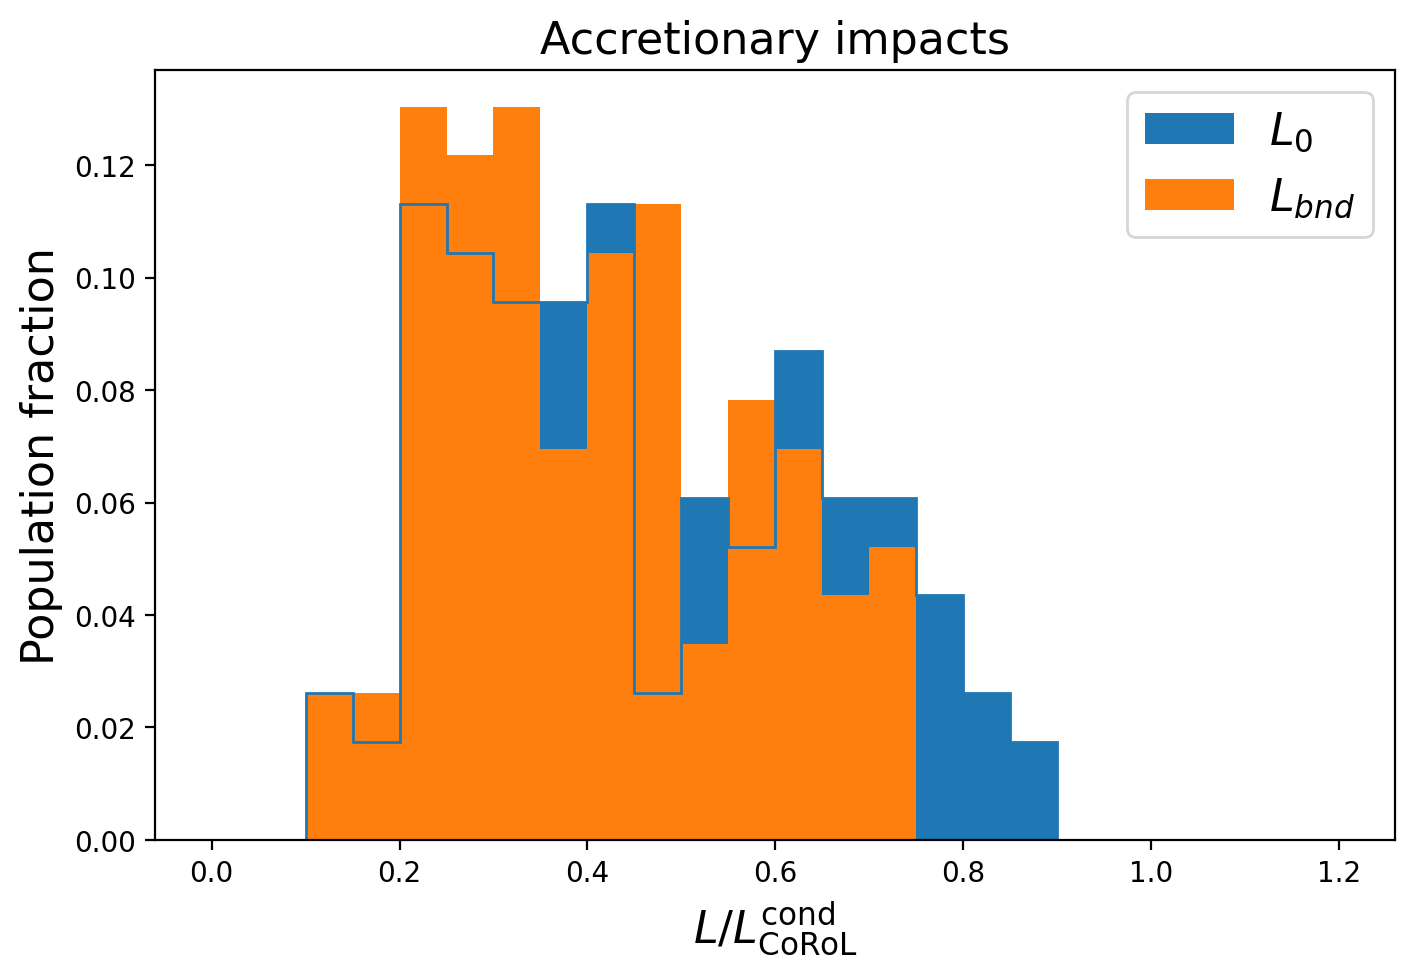

In [25]:
COROL_hist([accretionlistno0],bins=np.arange(0,1.25,.05),title='Accretionary impacts',savefig='accretion_hist',combined=True)

1
[0.00862069 0.04310345 0.21551724 0.04310345 0.01724138 0.0862069
 0.11206897 0.06034483 0.05172414 0.05172414 0.09482759 0.06034483
 0.04310345 0.01724138 0.02586207 0.00862069 0.02586207 0.00862069
 0.00862069 0.01724138 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ] [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7 ]
Median: 0.3362965003946372


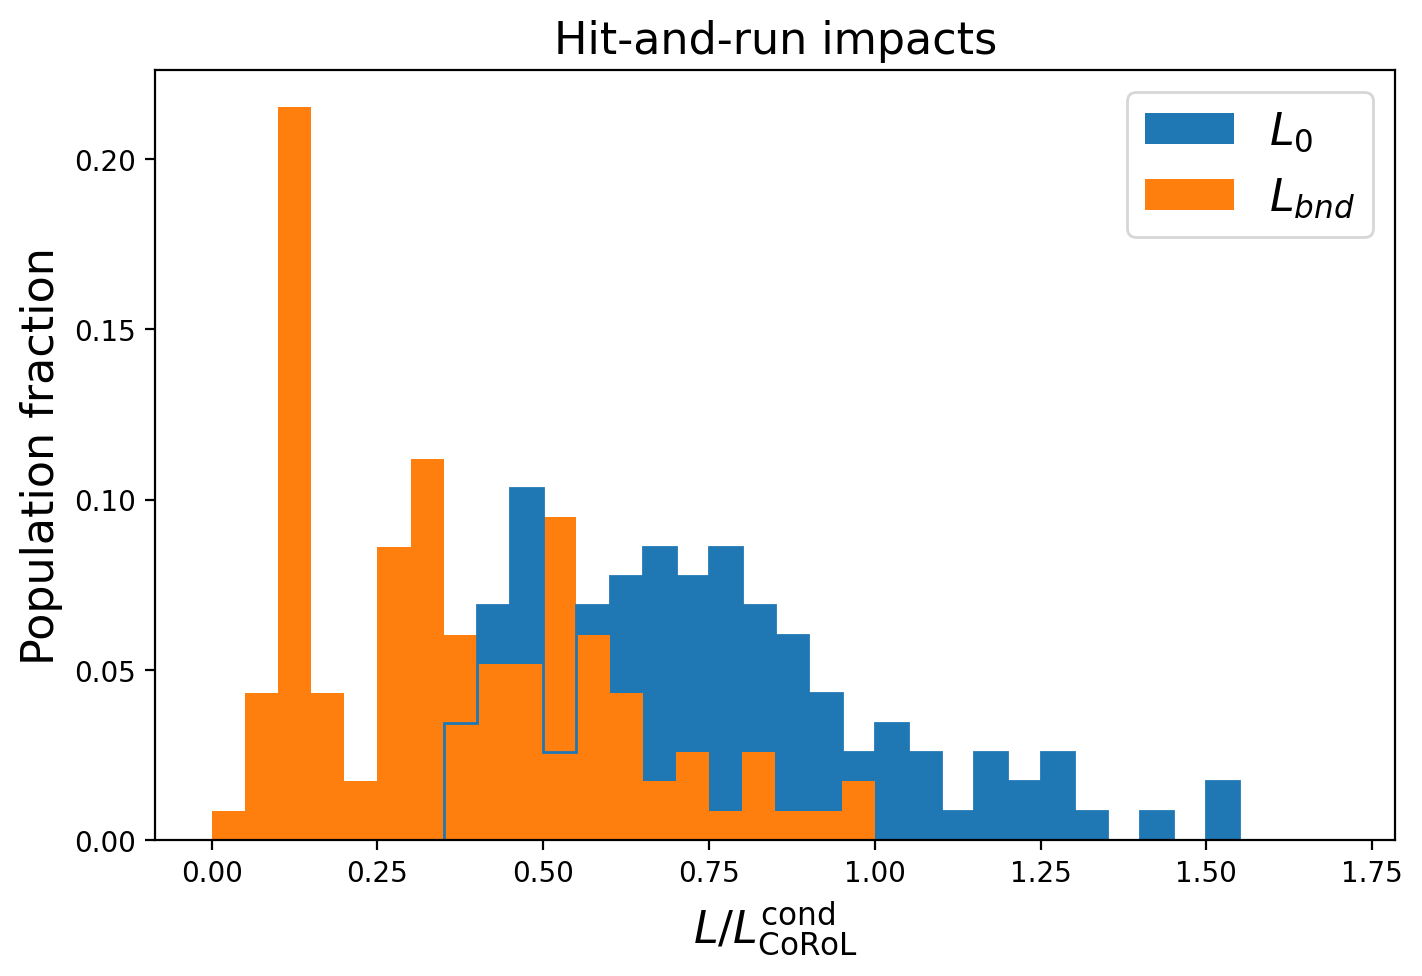

In [26]:
COROL_hist([hitandrunlist],bins=np.arange(0,1.75,.05),title='Hit-and-run impacts',savefig='hnr_hist_all',combined=True)

In [27]:
def synestia_hist(simlistlist,ax=None,labels=None,xlim=None,star=False,loglog=False,legend=True,colors=None,Lzstar=False,title=None,savefig=None,corolfn=corot,L0=False,bins=10):
    #infernomap = plt.cm.get_cmap('gnuplot2_r',3)
    #norm=colors.Normalize(vmin=0,vmax=2,clip=True)
    if ax is None: 
        fig,ax=plt.subplots(1,1,figsize=(8,5))
        axset=True
    else: axset=False

    count=0
    allLz=np.array([])
    allLz0=np.array([])
    allLz1=np.array([])
    allLz2=np.array([])
    for i in range(len(simlistlist)):
        simlist = simlistlist[i]
        for j in range(np.size(simlist)):
            sim=simlist[j]  
            allLz=np.append(allLz,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
            if sim.synflag==0:
                allLz0=np.append(allLz0,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
            if sim.synflag==1:
                allLz1=np.append(allLz1,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
            if sim.synflag==2:
                allLz2=np.append(allLz2,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
    
    #allLz0/=len(allLz)
    #allLz1/=len(allLz)
    #allLz2/=len(allLz)

    ax.hist([allLz0,allLz1,allLz2],bins=bins,density=False,fill=True,histtype='barstacked',stacked=True,label=['Planet + Disk','Synestia','Co-CoRoL'])
    
    #print(counts1/np.size(histarr),bins1)
    #print('Median:',np.median(histarr))
    #ax.stairs(counts1/np.size(histarr),bins1,fill=True,label=flabel)
    ax.set_xlabel(r'$L/L_\text{CoRoL}^\text{cond}$',size=16)
    ax.set_ylabel('Population counts',size=16)
    ax.legend(fontsize=16)
    if title is not None:
        ax.set_title(title,size=16)
    if axset:
        if savefig is not None:
            imname=savefig+'.pdf'
            plt.savefig(imname,bbox_inches='tight')
        plt.show()


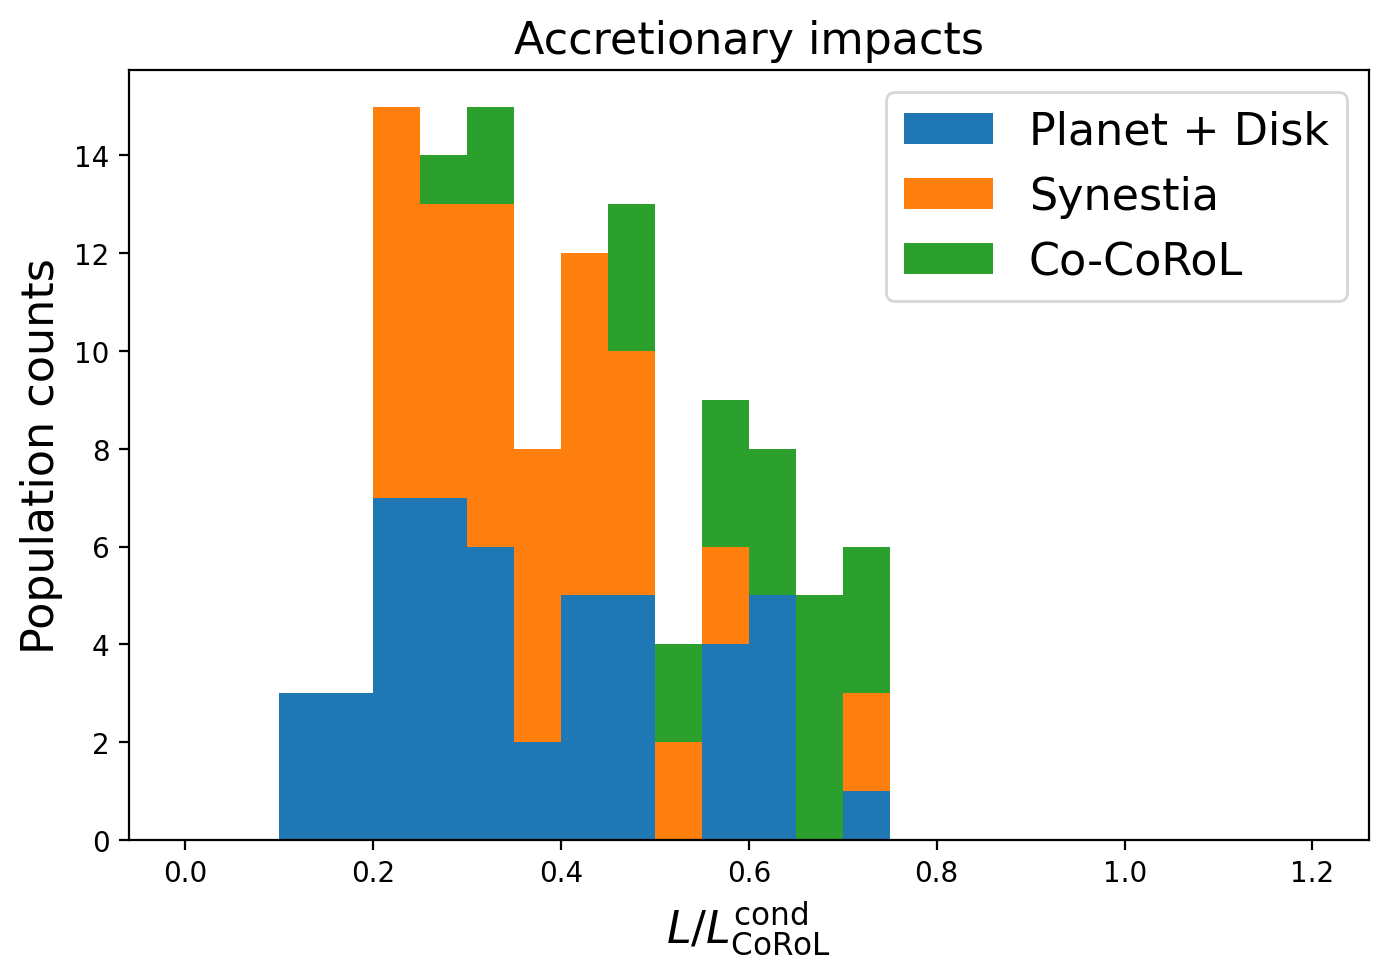

In [28]:
synestia_hist([accretionlistno0],bins=np.arange(0,1.25,.05),title='Accretionary impacts',savefig='synestia_hist')

In [29]:
def bigfit_ML(M,L):
    c00=153.53959723963789
    c01=0.6633160603278092
    c02=-0.9592188598031302
    c10=243.19051119279166
    c11=-3.366759602220585
    c12=-22.041247448477787
    c20=-18.332505614890877
    c21=-2.6533013645110426
    c22=-1.6783109326520955
    c30=2.780157903976064
    c31=-4.267852305563586
    c32=-1.874789905348047
    # need M in M_earth and L in L_EM
    return c00*M**c01*np.exp(c02*np.exp(-M))+c10*M**c11*np.exp(c12*np.exp(-M))*L+c20*M**c21*np.exp(c22*np.exp(-M))*L**2+c30*M**c31*np.exp(c32*np.exp(-M))*L**3

In [30]:
from matplotlib.colors import Normalize

def CoRoL_LM(simlistlist,ax=None,labels=None,xlim=None,star=False,loglog=False,markers=None,legend=True,colors=None,Lzstar=False,title=None,savefig=None):
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    if ax is None: 
        fig,ax=plt.subplots(1,1,figsize=(14,8))
        axset=True
    else: axset=False
    count=0
    allQS=np.array([])
    allLz=np.array([])
    allP=np.array([])
    allLcorols=np.array([])
    for i in range(np.shape(simlistlist)[0]):
        simlist = simlistlist[i]
        Lzs=np.zeros(np.size(simlist))
        QSs=np.zeros(np.size(simlist))
        Ps=np.zeros(np.size(simlist))
        for j in range(np.size(simlist)):
            sim=simlist[j]
            if Lzstar: Lzs[j]=sim.Lzbnd/sim.Lzstar
            else: 
                Lzs[j]=sim.Lzbnd
            QSs[j] = sim.QS
            allLz=np.append(allLz,Lzs[j])
            allQS=np.append(allQS,QSs[j])
            Ps[j]=bigfit_ML(sim.Mbound,sim.Lzbnd)
            allP=np.append(allP,Ps[j])
            allLcorols=np.append(allLcorols,Lzs[j]/corot(sim.Mbound))
    if colors=='Lz': 
        if Lzstar: pltnorm=Normalize(vmin=np.amin(allLz),vmax=np.amax(allLz))
        else: pltnorm=LogNorm(vmin=np.amin(allLz),vmax=1,clip=True)
    if colors=='LCoRoL':
        pltnorm=Normalize(vmin=0,vmax=1)
    if colors=='QS': pltnorm=LogNorm(vmin=np.amin(allQS),vmax=np.amax(allQS))
    if colors=='P': pltnorm=Normalize(vmin=0,vmax=1)

    lspace=np.linspace(1e-4,2)
    L0space=bigfit_ML(lspace,np.zeros(np.size(lspace)))
    corolspace=bigfit_ML(lspace,corot(lspace))

    ax.fill_between(lspace,0.7*L0space,0.8*L0space,color="lightgrey",label='Empirical equilibration P',alpha=.5)
    
    synmarkers=["o","*","*"]
    synlabel=['Post-impact: Planet + Disk','Synestia','Co-CoRoL']

    sclist=np.zeros(3)
    for i in range(np.shape(simlistlist)[0]):
        simlist = simlistlist[i]
        QSs=np.zeros(np.size(simlist))
        Lzs=np.zeros(np.size(simlist))
        Ps=np.zeros(np.size(simlist))
        Ms=np.zeros(np.size(simlist))
        for j in range(np.size(simlist)):
            sim=simlist[j]
            if markers=='theta':marker=sim.thetamarker
            elif markers=='size':marker=sim.sizemarker
            elif markers=='ratio':marker=sim.ratiomarker
            elif markers=='outcome':marker=sim.outcomemarker
            elif markers=='synestia':marker=synmarkers[int(sim.synflag)]
            if markers is None:marker=markerlist[(count//10)%np.size(markerlist)]
            if Lzstar: Lzs[j]=sim.Lzbnd/sim.Lzstar
            else: Lzs[j]=sim.Lzbnd
            if star:
                QSs[j] = sim.QstarS
                #logallQS=np.append(logallQS,np.log10(sim.QstarS))
            else:
                QSs[j] = sim.QS
                #logallQS=np.append(logallQS,np.log10(sim.QS))
            Ms[j]=sim.Mbound
            Ps[j]=bigfit_ML(sim.Mbound,sim.Lzbnd)
            if labels is None:
                if colors is not None:
                    if colors=='Lz':c=Lzs[j]
                    if colors=='QS':c=QSs[j]
                    if colors=='P':c=Ps[j]
                    if colors=='LCoRoL':c=Lzs[j]/corot(sim.Mbound)
                    if sclist[int(sim.synflag)]==0:
                        if sim.synflag!=2: ax.scatter(Ms[j],Ps[j],label=synlabel[int(sim.synflag)],s=65,marker=marker,c=(0.5+0.1*sim.synflag),norm=pltnorm,cmap='viridis')
                        sclist[int(sim.synflag)]+=1
                    ax.scatter(Ms[j],Ps[j],label=None,s=65,marker=marker,c=c,norm=pltnorm,cmap='viridis')
                else:
                    ax.scatter(Ms[j],Ps[j],label=None,s=65,marker=marker)
                count+=1
        if labels is not None:
            #if logfit:
            ax.scatter(Ms,Ps,label=labels[i],s=65,marker=marker)

    ax.plot(lspace,L0space,color='k',label=r'Non-rotating P$_{\rm CMB}$')
    ax.plot(lspace,corolspace,color='red',ls='--',label=r'P$_{\rm CMB}$ @ L$^{\rm cond}_{\rm CoRoL}$')
    
    if colors is not None:
        cbar=plt.colorbar(cm.ScalarMappable(norm=pltnorm, cmap='viridis'), ax=ax)
        #cbar=plt.colorbar(cm.ScalarMappable(cmap='viridis'), ax=ax)
        cbar.ax.tick_params(which='major', labelsize=17)
        if colors=='Lz':
            if Lzstar:cbar.set_label('LzBound/L*',size=18)#,size=22
            else:cbar.set_label(r'Planet $L_Z$',size=18)#,size=22
        if colors=='QS':cbar.set_label('$Q_S$ [J/kg]',size=18)#,size=22
        if colors=='P':cbar.set_label(r'$P_{\rm CMB}/P_{\rm CMB,CoRoL}$',size=18)
        if colors=='LCoRoL':cbar.set_label(r'$L/L^{\rm cond}_{\rm CoRoL}$',size=20)
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.tick_params(axis='both', which='minor', labelsize=17)
    ax.set_xlabel(r'Largest Remnant Mass (M$_{\oplus}$)',size=20)#,size=24
    ax.set_ylabel(r'Condensed, Rotating CMB Pressure (GPa)',size=20)#,size=24
    #if legend: ax.legend(bbox_to_anchor=(1.3, 1.0), loc='upper left')#,fontsize=14
    if legend: ax.legend(loc='upper left',fontsize=18)#,fontsize=14
    if loglog:
        ax.set_yscale('log')
    #ax.set_xlim(0,None)
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    if title is not None:
        ax.set_title(title,size=16)
    if axset:
        if savefig is not None:
            imname=savefig+'.pdf'
            plt.savefig(imname,bbox_inches='tight')
        plt.show()

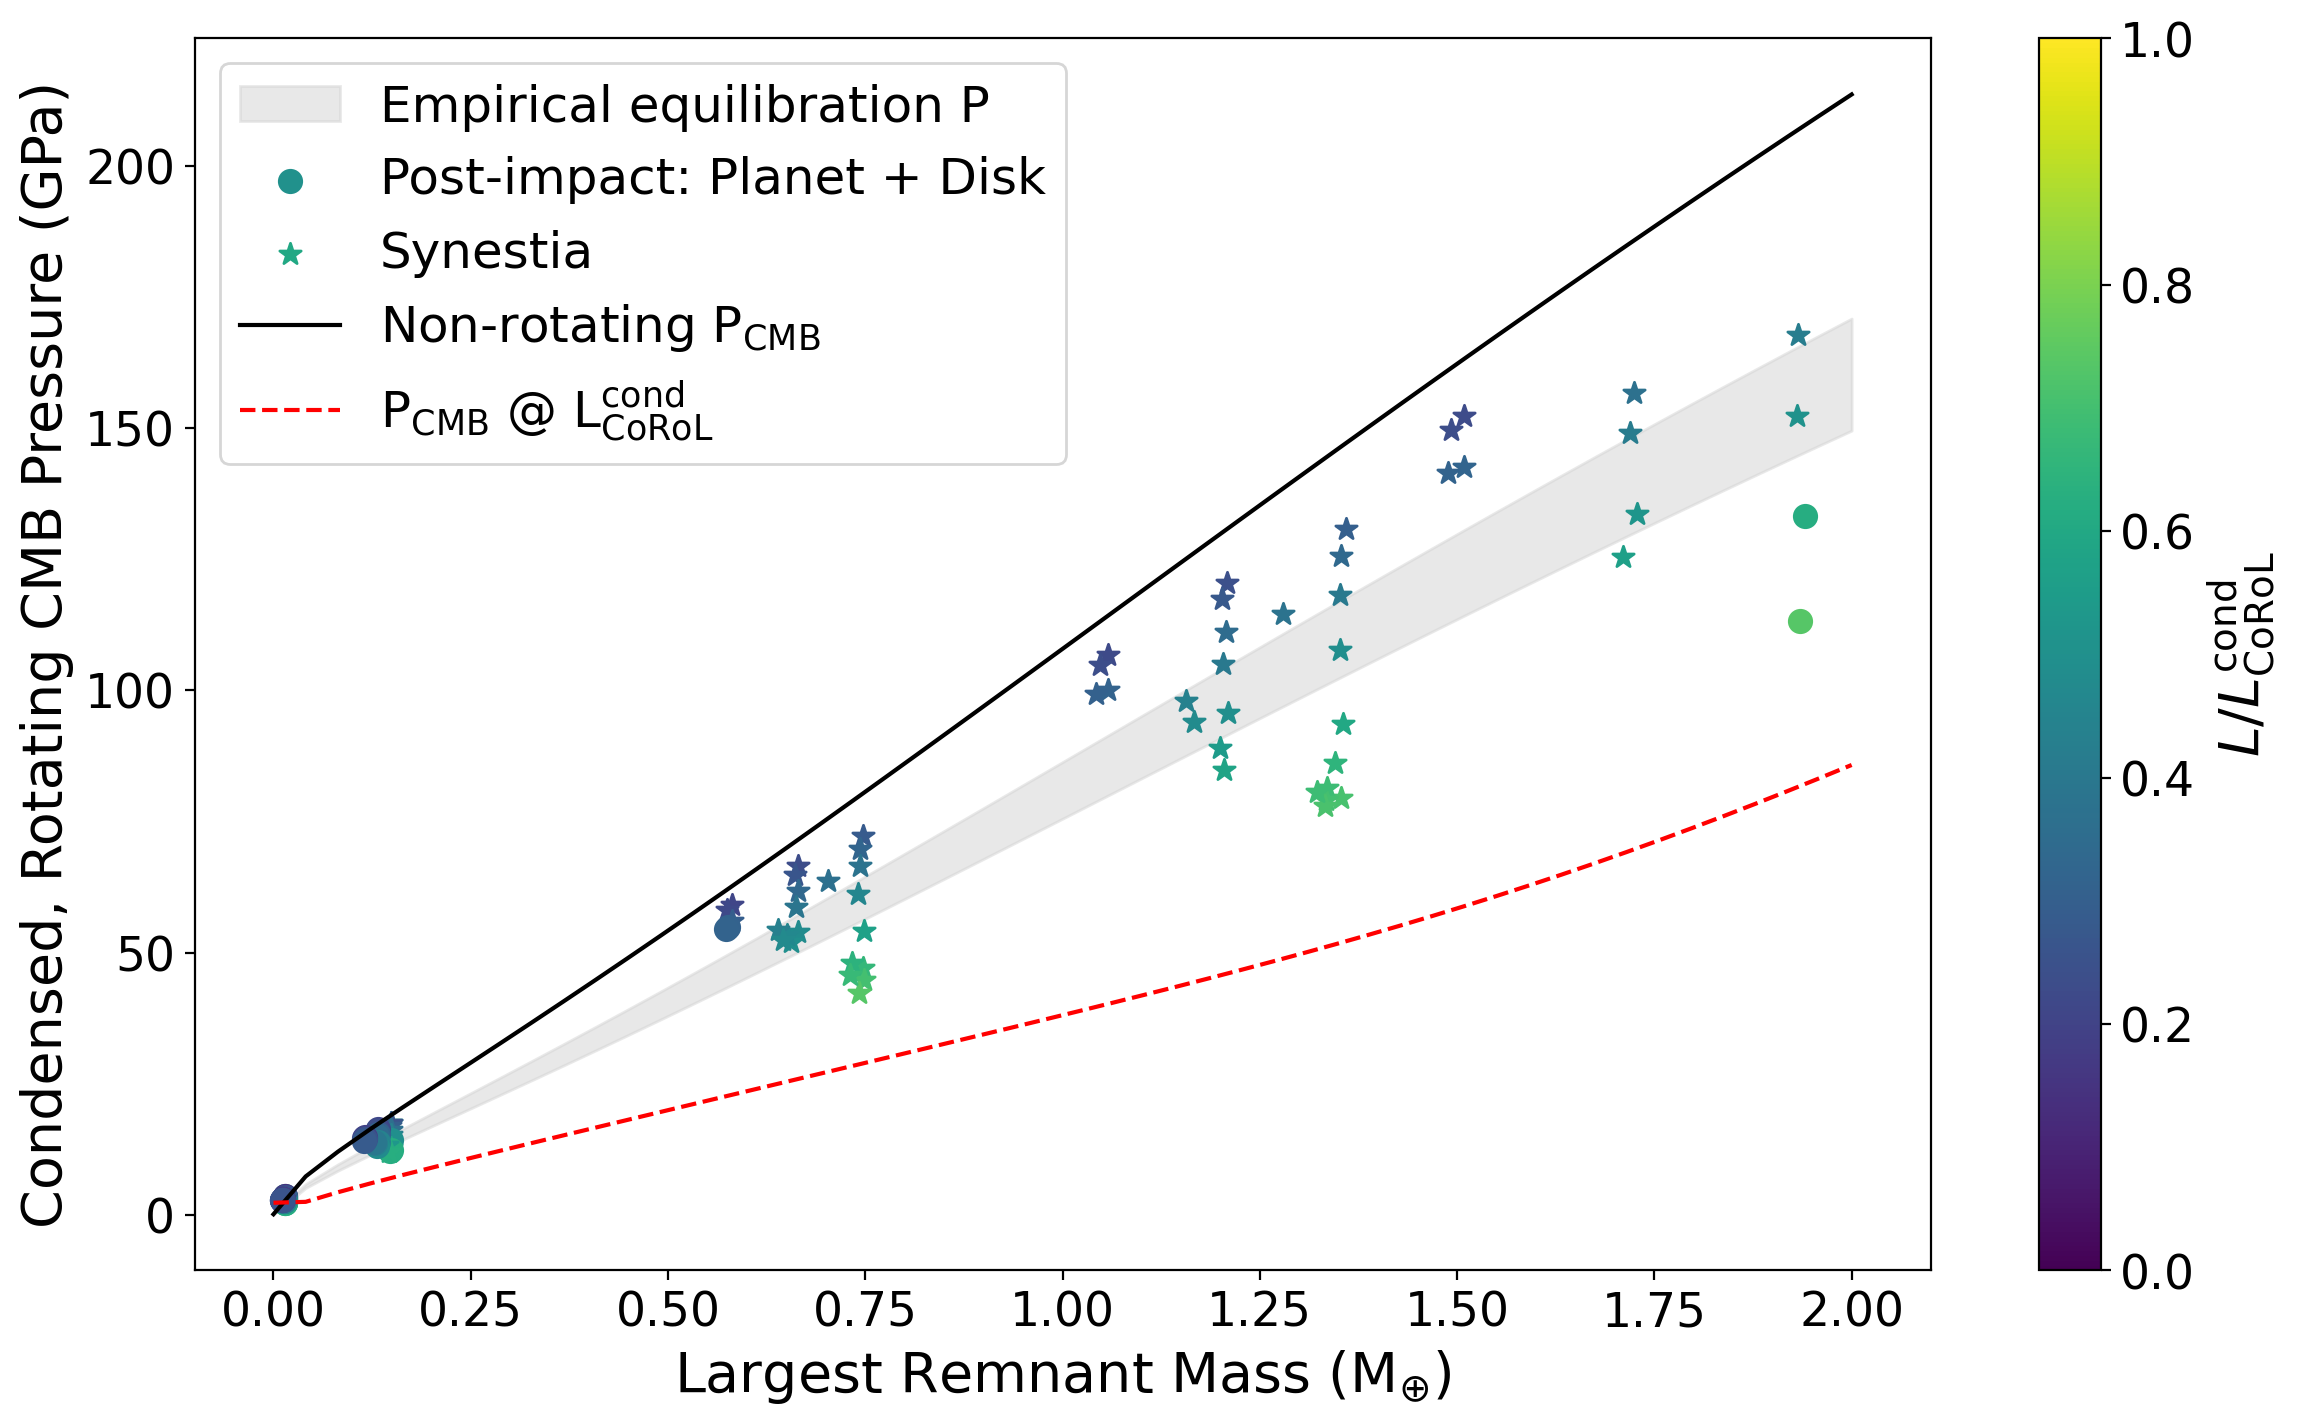

In [31]:
CoRoL_LM([accretionlistno0],labels=None,loglog=False,colors='LCoRoL',legend=True,markers='synestia',title=None,savefig='postema_CoRoL_diagram')

### Sarah Figures

wrote fig_synestia_criteria.pdf / .png   (J_crit = 1.42 M^1.19 QS^-0.40)


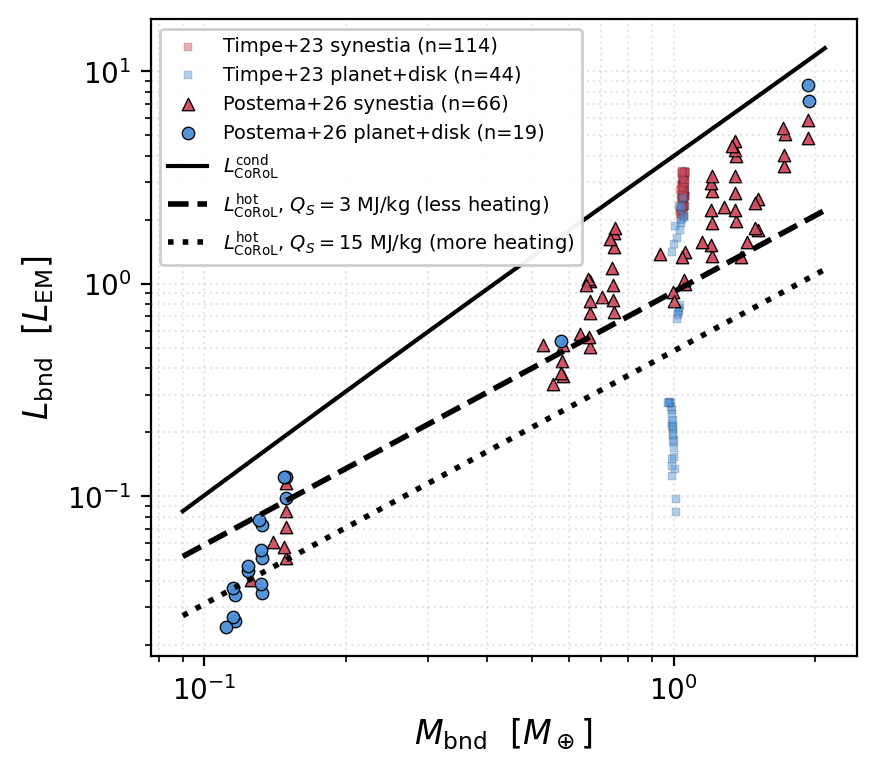

In [32]:
### FIG:SYNESTIA_CRITERIA
import os
from corotation_limit import L_corot, L_canup
J_EM = 3.61e34

HERE = (os.getcwd())   # run from anywhere; data sits beside script
#HERE = os.path.dirname(os.path.abspath(os.getcwd()))   # run from anywhere; data sits beside script
D = pd.read_csv(f"{HERE}/joint_synestia_data.csv")
A, pQS, pM = np.load(f"{HERE}/_joint_coef.npy")

P = D[D.src == 'Postema']; T = D[D.src == 'TM']
fig, ax = plt.subplots(figsize=(4.5, 4))

# TM (non-rotating, grazing) small dots by HSSL label
for lab, sub, c in [('Timpe+23 synestia', T[T.syn==1], '#d1495b'),
                    ('Timpe+23 planet+disk',                 T[T.syn==0], '#4a90d9')]:
    ax.scatter(sub.M, sub.J, s=10, marker='s', facecolor=c, alpha=0.45, edgecolor='k', linewidth=0.1, label=f'{lab} (n={len(sub)})')

# Postema markers by label
for lab, sub, mk, c in [('Postema+26 synestia', P[P.syn==1], '^', '#d1495b'),
                        ('Postema+26 planet+disk',       P[P.syn==0], 'o', '#4a90d9')]:
    ax.scatter(sub.M, sub.J, s=20, marker=mk, facecolor=c, edgecolor='k',
               linewidth=0.5, alpha=0.95, label=f'{lab} (n={len(sub)})')

MM = np.logspace(np.log10(0.09), np.log10(2.1), 100)
LL = L_corot(MM, type=4)
ttt = r'$L_{\rm CoRoL}^{\rm hot}$'
ax.plot(MM,LL,'k-',label=r'$L_{\rm CoRoL}^{\rm cond}$')
for QS, ls, lab in [(3.0, '--', r'$Q_S=3$ MJ/kg (less heating)'),
                    (15.0, ':',  r'$Q_S=15$ MJ/kg (more heating)')]:
    ax.plot(MM, A * MM**pM * QS**pQS, color='k', ls=ls, lw=2,
            label=f'{ttt}, {lab}')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M_{\rm bnd}$  [$M_\oplus$]', fontsize=12)
ax.set_ylabel(r'$L_{\rm bnd}$  [$L_{\rm EM}$]', fontsize=12)
#ax.set_title('Joint synestia criterion (non-rotating TM + Postema)\n'
#             r'$J_{\rm bound} > %.2f\,M^{%.2f}\,Q_S^{%.2f}$   (AM $\uparrow$ mass, $\downarrow$ heating)'
#             % (A, pM, pQS), fontsize=11)
ax.legend(fontsize=7, loc='upper left', framealpha=0.95)
ax.grid(True, which='both', ls=':', alpha=0.3)
fig.tight_layout()
fig.savefig(f"{HERE}/fig_synestia_criteria.pdf", bbox_inches='tight')
fig.savefig(f"{HERE}/fig_synestia_criteria.png", dpi=150, bbox_inches='tight')
print(f"wrote fig_synestia_criteria.pdf / .png   (J_crit = {A:.2f} M^{pM:.2f} QS^{pQS:.2f})")
plt.show()

Quintana+16 (a): N=916, synestia 318 (35%), M_lr 0.144-1.801, median P/P0=0.719
Clement+19 (b): N=532, synestia 62 (12%), M_lr 0.056-1.900, median P/P0=0.786
Clement+23 (c): N=149, synestia 23 (15%), M_lr 0.056-1.537, median P/P0=0.756
wrote fig_nbody_collisions.png / .pdf


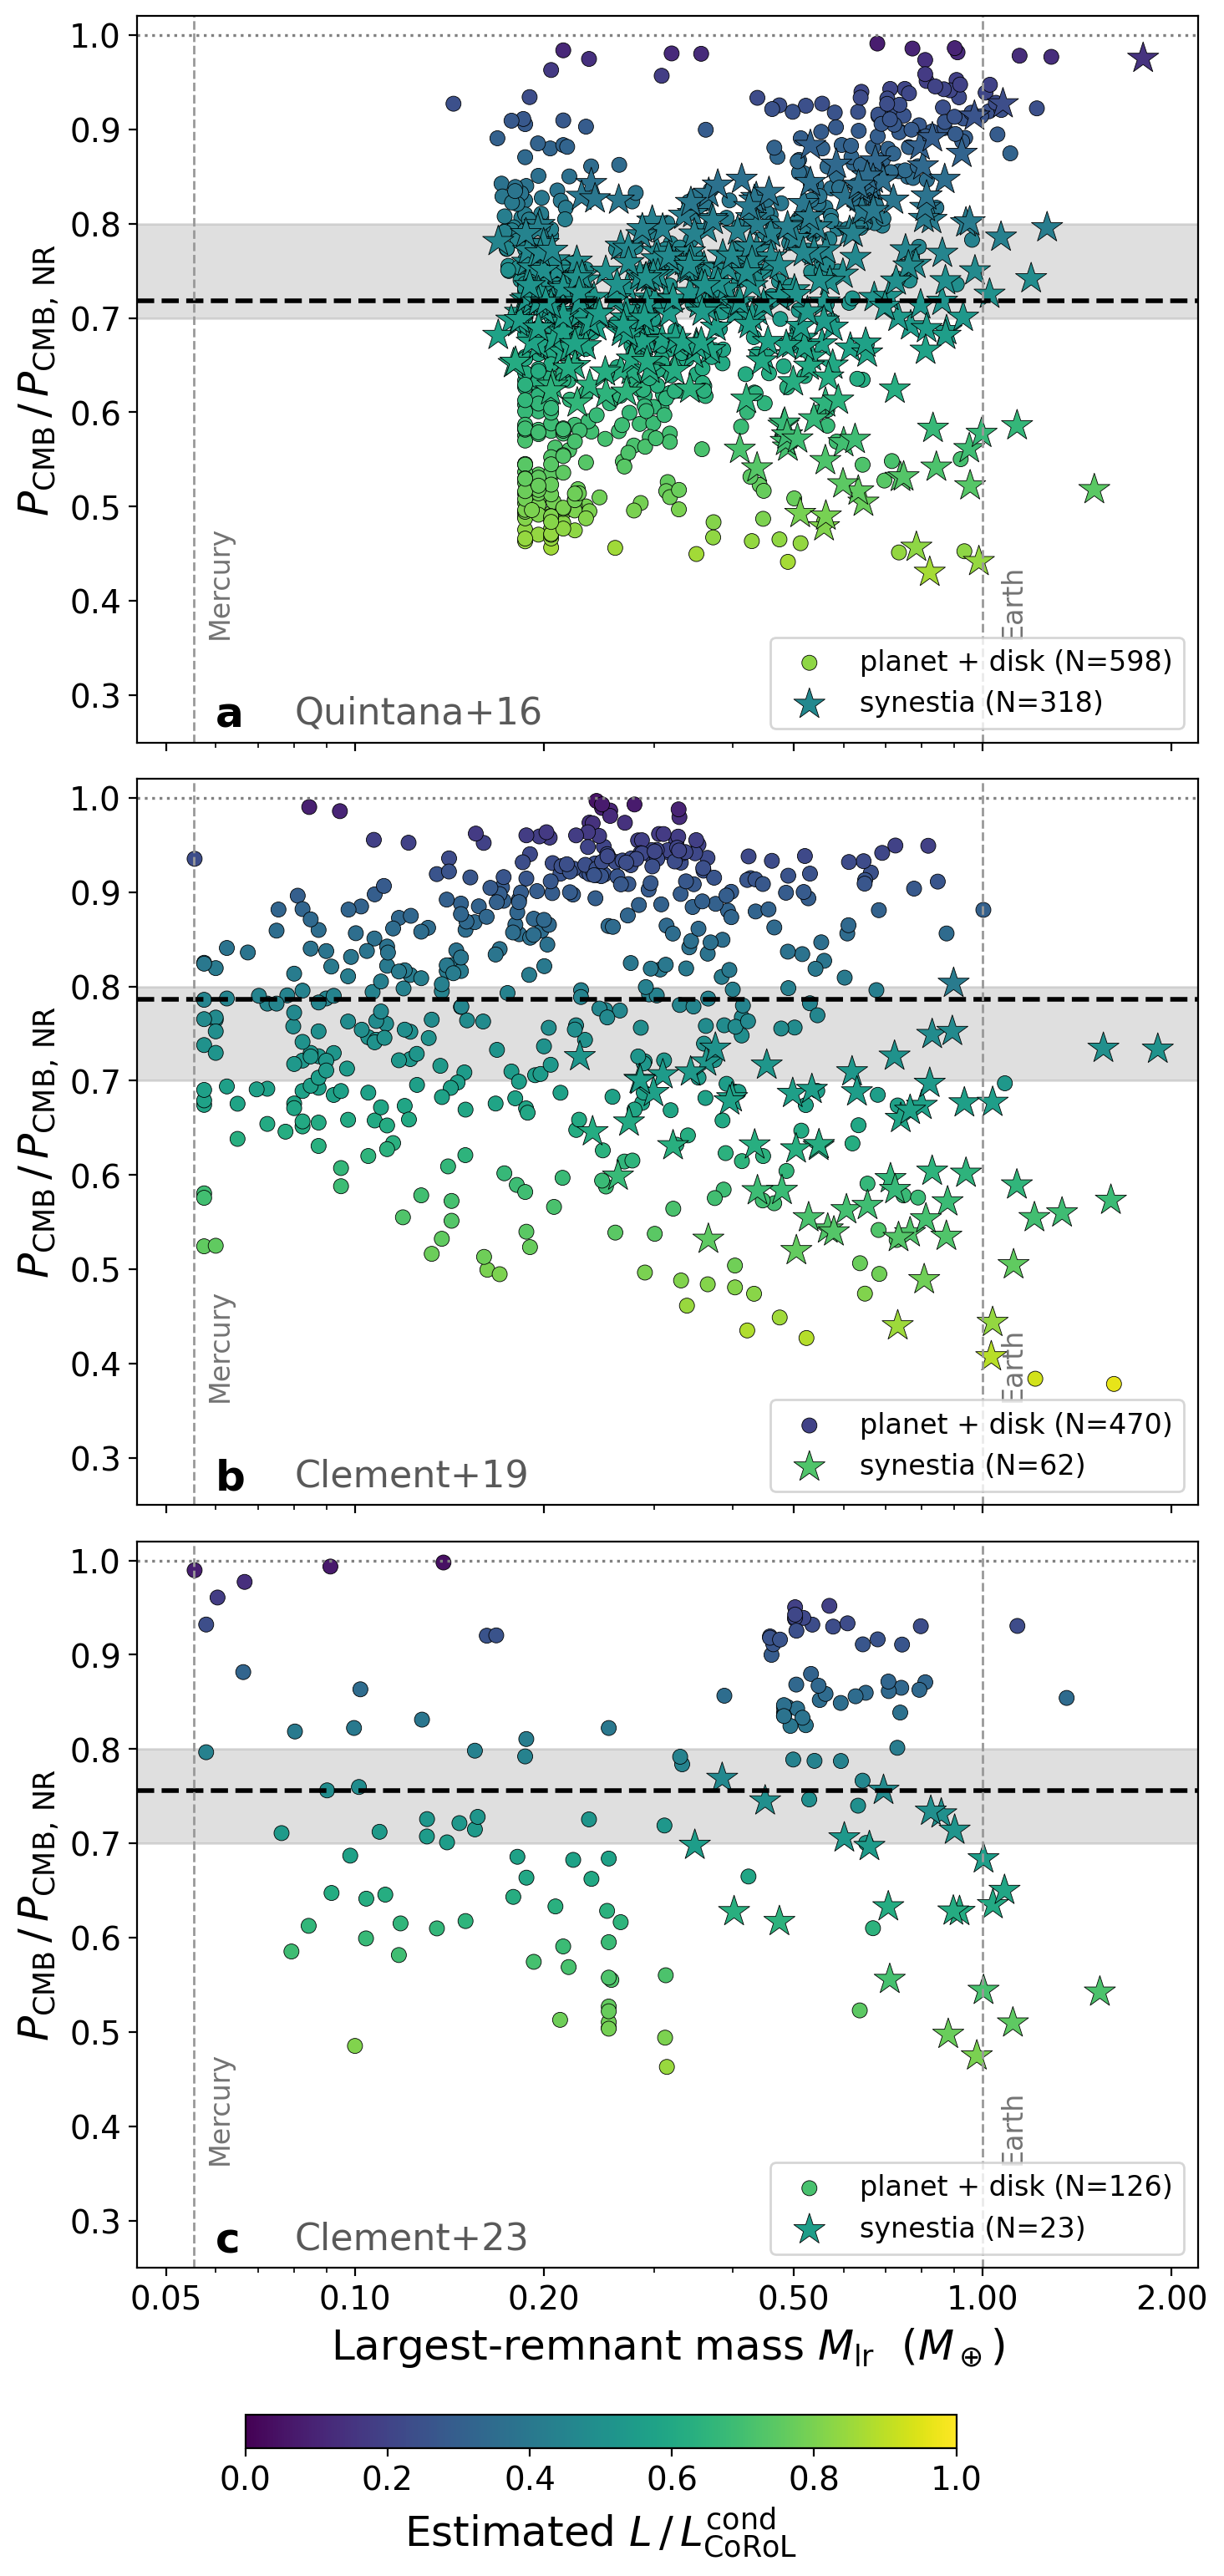

In [35]:
### FIG:NBODY COLLISIONS
import glob
import pandas as pd

from corotation_limit import L_corot
from Jbound_scaling_law import J_bound_nonrotating_broad
from qs_lock import QS_modified

ME, LEM, JEM = 5.972e24, 3.5e34, 3.61e34
M_MERC = 0.0553                      # Mercury mass [M_earth]
ACC = ['Merge', 'Perfect', 'Graze+Merge']
A_SYN, pQS, pM = np.load('_joint_coef.npy')   # [A, pQS, pM] = 1.42, -0.40, 1.19

# --- Postema+25 Eq 7 / Table 4 : P_CMB(M,L) (robust to low mass) --------------
C_TAB4 = np.array([[153.528, 0.663378, -0.959155], [63.3206, -2.22476, -18.474],
                   [-17.742, -2.63846, -1.60827], [2.61647, -4.23984, -1.74688]])
def _gi(i, M): c = C_TAB4[i]; return c[0]*M**c[1]*np.exp(c[2]*np.exp(-M))
def P_ratio(M, L): return sum(_gi(i, M)*L**i for i in range(4)) / _gi(0, M)

def derive(M, Mt, Mp, Rt, Rp, vimp, b, gamma, vve):
    """(P_CMB/P_norot, L/L_CoRoL, synestia_flag)."""
    Lcor = L_corot(M, type=4)*JEM/LEM                       # condensed Type-4 CoRoL
    mu   = Mt*Mp/(Mt+Mp)
    Limp = mu*vimp*b*(Rt+Rp)
    eta  = J_bound_nonrotating_broad(gamma, vve, b, 1.0)    # scale-free retention law
    Jb   = np.nan_to_num(eta)*Limp/LEM                      # bound AM estimate [L_EM]
    Lret = np.minimum(Jb, Lcor)
    QS   = QS_modified(Mt, Mp, vimp, b, Rt, Rp) / 1e6       # MJ/kg
    syn  = Jb > A_SYN * M**pM * QS**pQS                     # empirical synestia criterion
    return P_ratio(M, Lret), Lret/Lcor, syn

# --- Clement raw loaders (re-extract with the low M_lr floor) -----------------
def load_clement(root, embprefix):
    frames = []
    for f in sorted(glob.glob(os.path.join(root, '*', 'collisions.txt'))):
        frames.append(pd.read_csv(f))
    d = pd.concat(frames, ignore_index=True)
    emb = lambda s: s.str[0].isin(list(embprefix))
    a = d[emb(d.target) & emb(d.projectile) & d.Regime.isin(ACC)].copy()
    a['Mlr'] = a.Mt_Mearth + a.Mp_Mearth - a['m_frag_Mearth']
    a['xi']  = (a.Mlr - a.Mt_Mearth) / a.Mp_Mearth
    a['gam'] = a.Mp_Mearth / a.Mt_Mearth
    return a[(a.Mlr > M_MERC) & (a.xi >= 0.8) & (a.gam > 0.1)].copy()

def derive_clement(c):
    return derive(c.Mlr.values, c.Mt_Mearth.values*ME, c.Mp_Mearth.values*ME,
                  c.Rt_km.values*1e3, c.Rp_km.values*1e3, c['vimp_km/s'].values*1e3,
                  c.b.values, c.gam.values, c['vimp/vesc'].values)

# --- assemble the three datasets ---------------------------------------------
q = pd.read_csv('quintana_collisions.csv')
q = q[(q.Mlr_ME > M_MERC) & (q.xi >= 0.8) & (q.gamma > 0.1)]
qPr, qLo, qS = derive(q.Mlr_ME.values, q.Mt.values, q.Mp.values, q.Rt.values, q.Rp.values,
                      q.Vimp.values, q.b.values, q.gamma.values, q.vve.values)

c1 = load_clement('clement/sims_for_sarah', 'E')
c1Pr, c1Lo, c1S = derive_clement(c1)
c2 = load_clement('clement/sims_for_sarah2_c23', 'EM')
c2Pr, c2Lo, c2S = derive_clement(c2)

panels = [('a', 'Quintana+16', q.Mlr_ME.values, qPr, qLo, qS),
          ('b', 'Clement+19', c1.Mlr.values, c1Pr, c1Lo, c1S),
          ('c', 'Clement+23', c2.Mlr.values, c2Pr, c2Lo, c2S)]

# font sizes
fs1=18 # main labels
fs2=16 # on plot
fs3=12 # small
# ================================ plot ======================================
LBL = dict(fontsize=fs1, color='k')
fig, axs = plt.subplots(3, 1, figsize=(7.6, 15.4), sharex=True)
common = dict(cmap='viridis', vmin=0, vmax=1, edgecolors='k', lw=0.3)
for ax, (lab, name, M, Pr, Lo, S) in zip(axs, panels):
    ax.fill_between([0,3],[.7,.7],[.8,.8],color='grey',alpha=0.25)
    sc = ax.scatter(M[~S], Pr[~S], c=Lo[~S], s=42, marker='o',
                    label=f'planet + disk (N={int((~S).sum())})', **common)
    ax.scatter(M[S], Pr[S], c=Lo[S], s=200, marker='*',
               label=f'synestia (N={int(S.sum())})', **common)
    ax.axhline(np.median(Pr),color='k',ls='--',lw=2)
    ax.axhline(1.0, color='0.5', ls=':', lw=1.2)
    ax.axvline(M_MERC, color='0.6', ls='--', lw=1.0)
    ax.axvline(1.0, color='0.6', ls='--', lw=1.0)
    ax.text(0.058, 0.36, 'Mercury', fontsize=fs3, color='0.45', rotation=90, va='bottom')
    ax.text(1.06, 0.36, 'Earth', fontsize=fs3, color='0.45', rotation=90, va='bottom')
    ax.text(0.06, 0.3, lab, fontsize=fs1, fontweight='bold', va='top') #abc
    ax.text(0.08, 0.3, name, fontsize=fs2, color='0.35', va='top') # study
    ax.set_ylabel(r'$P_{\rm CMB}\,/\,P_{\rm CMB,\,NR}$', **LBL)
    ax.set_ylim(0.25, 1.02); ax.set_xlim(0.045, 2.2); ax.set_xscale('log')
    ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
    ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=fs3, loc='lower right')
axs[-1].set_xlabel(r'Largest-remnant mass $M_{\rm lr}$  $(M_\oplus)$', **LBL)

fig.subplots_adjust(left=0.135, right=0.97, top=0.99, bottom=0.115, hspace=0.05)
cax = fig.add_axes([0.22, 0.045, 0.56, 0.013])
cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
cb.set_label(r'Estimated $L\,/\,L_{\rm CoRoL}^{\rm cond}$', **LBL)
cb.ax.tick_params(labelsize=14)
fig.savefig('fig_nbody_collisions', dpi=140)
fig.savefig('fig_nbody_collisions.pdf')
for lab, name, M, Pr, Lo, S in panels:
    print(f'{name} ({lab}): N={len(M)}, synestia {int(S.sum())} ({100*S.mean():.0f}%), '
          f'M_lr {M.min():.3f}-{M.max():.3f}, median P/P0={np.median(Pr):.3f}')
print('wrote fig_nbody_collisions.png / .pdf')
plt.show()

wrote fig_bound_am.png   (N=486, RMS(eta)=0.103)


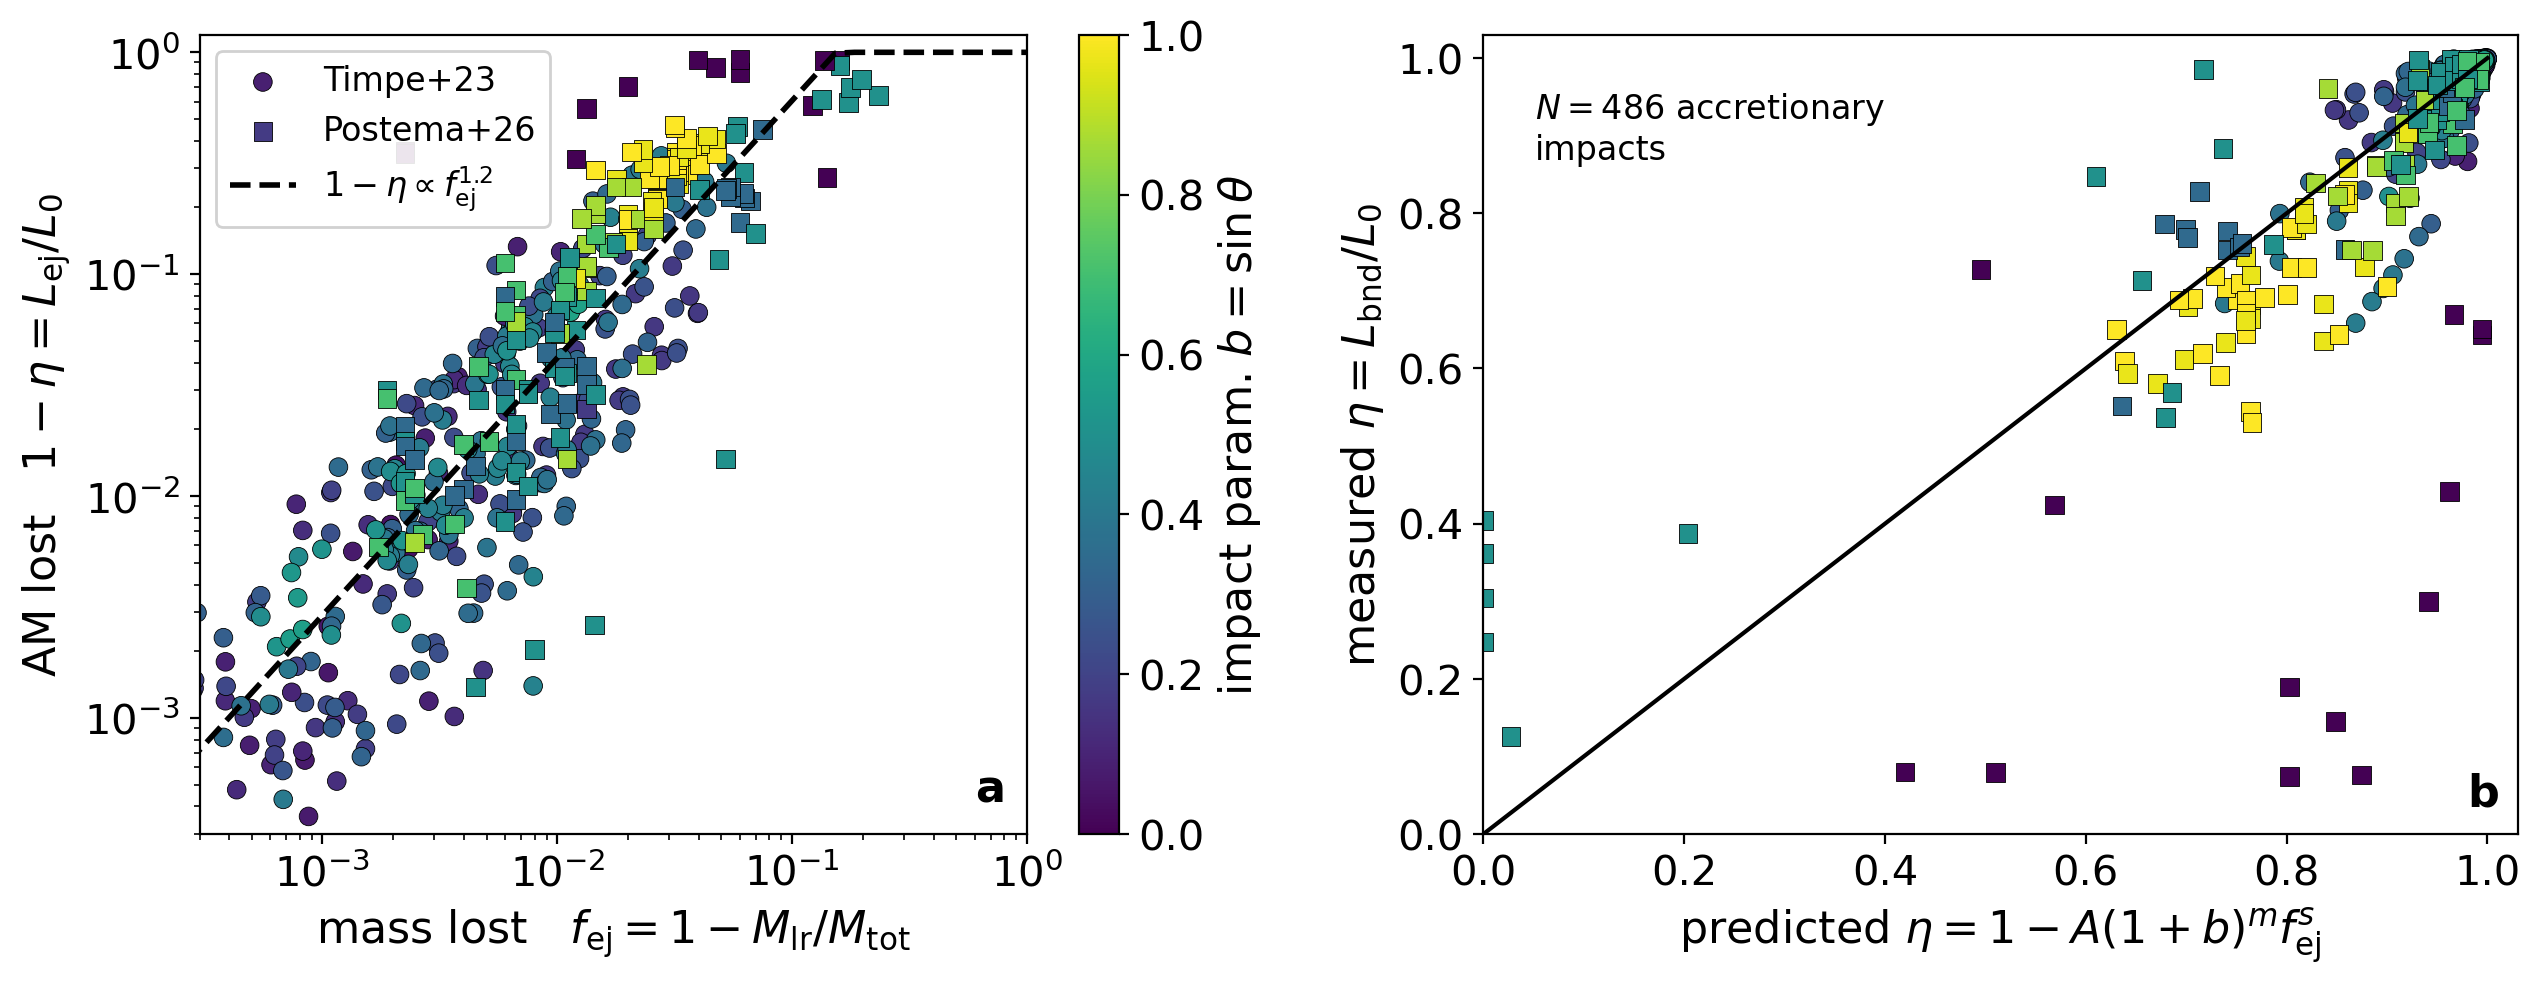

In [36]:
### FIG:BOUND AM

from explore_ejecta_AM import assemble

A, m, s = 4.362941299820175, 1.274173427265838, 1.101167386820984   # eta = 1 - A(1+b)^m f_ej^s

d   = assemble()
acc = d[(d.xi > 0.2) & (d.f_ej > 1e-4) & ((1 - d.eta) > 1e-4)].copy()   # accretionary incl. graze-merge
acc['eta_pred'] = np.clip(1 - A*(1+acc.b)**m * acc.f_ej**s, 0, 1)
rms = np.sqrt(((acc.eta - acc.eta_pred)**2).mean())

plt.rcParams.update({'font.size': 15, 'axes.labelsize': 16, 'axes.titlesize': 17})
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
cmap = plt.cm.viridis

# ---- (A) AM lost vs mass lost
for src, mk, lab in [('TimpeMeier', 'o', 'Timpe+23'), ('Postema', 's', 'Postema+26')]:
    g = acc[acc.src == src]
    sc = ax[0].scatter(g.f_ej, 1 - g.eta, c=g.b, cmap=cmap, vmin=0, vmax=1,
                       marker=mk, s=45, edgecolor='k', linewidth=0.3, label=lab)
xx = np.logspace(-4, 0, 50)
ax[0].plot(xx, np.clip(8.77*xx**1.16, 0, 1), 'k--', lw=2, label=r'$1-\eta\propto f_{\rm ej}^{1.2}$')
ax[0].set(xscale='log', yscale='log', xlim=(3e-4, 1), ylim=(3e-4, 1.2),
          xlabel=r'mass lost   $f_{\rm ej}=1-M_{\rm lr}/M_{\rm tot}$',
          ylabel=r'AM lost   $1-\eta=L_{\rm ej}/L_0$')
#ax[0].set_title('AM lost tracks mass lost', fontweight='bold')
ax[0].legend(fontsize=12, loc='upper left', framealpha=0.9)
ax[0].text(.6,6.e-4,'a',fontsize=16,fontweight='bold',va='top') #ab
cb = fig.colorbar(sc, ax=ax[0]); cb.set_label(r'impact param. $b=\sin\theta$')

# ---- (B) predicted vs measured eta
for src, mk in [('TimpeMeier', 'o'), ('Postema', 's')]:
    g = acc[acc.src == src]
    ax[1].scatter(g.eta_pred, g.eta, c=g.b, cmap=cmap, vmin=0, vmax=1,
                  marker=mk, s=45, edgecolor='k', linewidth=0.3)
ax[1].plot([0, 1], [0, 1], 'k-', lw=1.5)
ax[1].set(xlim=(0, 1.03), ylim=(0, 1.03),
          xlabel=r'predicted $\eta = 1-A(1+b)^m f_{\rm ej}^{s}$',
          ylabel=r'measured $\eta = L_{\rm bnd}/L_0$')
#ax[1].set_title(f'retention law   (RMS $={rms:.2f}$)', fontweight='bold')
ax[1].text(0.05, 0.93, f'$N={len(acc)}$ accretionary\nimpacts',
           transform=ax[1].transAxes, fontsize=12, va='top')
ax[1].text(.98,.08,'b',fontsize=16,fontweight='bold',va='top') #ab

fig.tight_layout()
fig.savefig('fig_bound_am.png', dpi=150, bbox_inches='tight')
fig.savefig('fig_bound_am.pdf')
print(f'wrote fig_bound_am.png   (N={len(acc)}, RMS(eta)={rms:.3f})')
plt.show()